In [ ]:
# --- Bibliotecas principales para el manejo y análisis de datos ---
import pandas as pd # La biblioteca de referencia para la manipulación y el análisis de datos, ideal para gestionar nuestro conjunto de datos.
import numpy as np # Esencial para operaciones numéricas, especialmente con matrices.

# --- Bibliotecas de visualización ---
import matplotlib.pyplot as plt # La biblioteca fundamental para crear una amplia gama de visualizaciones estáticas, animadas e interactivas.
import seaborn as sns # Basada en Matplotlib, proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos.

# --- Scikit-Learn (sklearn) para Machine Learning ---
from sklearn.model_selection import train_test_split, GridSearchCV  # Herramientas para dividir nuestros datos en conjuntos de entrenamiento y prueba, y para ajustar los hiperparámetros de nuestro modelo.
from sklearn.ensemble import RandomForestClassifier # El modelo de Machine Learning que usaremos, un potente conjunto de árboles de decisión.
from sklearn.preprocessing import QuantileTransformer # Una herramienta para transformar nuestras características a una distribución uniforme o normal, lo que puede mejorar el rendimiento del modelo.
from sklearn.metrics import classification_report, confusion_matrix # Métricas clave para evaluar el rendimiento de nuestro modelo de clasificación.
from sklearn.feature_selection import chi2 # Usaremos la prueba de Chi-cuadrado para la selección de características y ver qué variables están más relacionadas con nuestro objetivo.
from sklearn.preprocessing import KBinsDiscretizer # Esto nos ayuda a discretizar datos continuos en intervalos para la prueba de Chi-cuadrado.

# --- Aprendizaje desequilibrado (imblearn) para el manejo de conjuntos de datos desequilibrados ---
from imblearn.combine import SMOTEENN # Una técnica eficaz para manejar clases desequilibradas mediante el sobremuestreo de la clase minoritaria y la limpieza de la clase mayoritaria.
from imblearn.pipeline import Pipeline # Un pipeline especial de imblearn que nos permite usar correctamente los muestreadores en un flujo de trabajo de validación cruzada.

# --- SciPy para pruebas estadísticas ---
from scipy.stats import pointbiserialr # Lo usaremos para la correlación punto-biserial para medir la relación entre nuestro objetivo binario y las variables continuas.


In [ ]:
# --- Función para cargar y limpiar el conjunto de datos ---
def leer_dataset():
    """
    Esta función lee el archivo 'data.csv', realiza una limpieza inicial eliminando las columnas innecesarias
    y prepara la variable de destino para nuestra tarea de clasificación.
    """
    df = pd.read_csv('data.csv')

    # Vamos a eliminar algunas columnas que no necesitamos para nuestro análisis.
    cols_to_drop = ['ALEAT', 'ID','VT']  # reemplaza por los nombres reales
    df = df.drop(columns=cols_to_drop)

    # Se renombran algunas columnas para mayor claridad y consistencia.
    df.rename(columns={'V31_P': 'V31'}, inplace=True)
    df.rename(columns={'V31_P.1': 'V31_P'}, inplace=True)

    # Se elimina la versión V14, ya que podría no ser relevante o presentar problemas.
    cols_to_drop = ['V14', 'V14_P']  
    df = df.drop(columns=cols_to_drop)

    # Necesitamos convertir nuestra variable objetivo 'OBJ' de texto ('NO'/'SI') a números (0/1) para que nuestros modelos puedan entenderla.
    df['OBJ']=df['OBJ'].map({'NO':0,'SI':1})
    
    return df

# --- Función para separar datos en subconjuntos ---
def subset_datos(df):
    """
    Esta función nos ayuda a organizar nuestros datos separando las columnas en tres grupos:
    1. Variables de valor absoluto (p. ej., V1, V2)
    2. Variables de valor relativo (p. ej., V1_P, V2_P)
    3. Variable objetivo/meta (OBJ)
    """
    absolutas=[col for col in df.columns if '_P' not in col and col != 'OBJ' and col != 'VT']
    relativas=[col for col in df.columns if '_P' in col]
    return df[absolutas], df[relativas], df['OBJ']

# --- Función para crear diagramas de caja ---
def plot_boxplot(df, columnas, titulo='Boxplot'):
    """
    Una función práctica para crear diagramas de caja.
    Son excelentes para visualizar la distribución de nuestros datos y para identificar valores atípicos que puedan requerir nuestra atención.
    """
    plt.figure(figsize=(15,6))
    sns.boxplot(data=df[columnas])
    plt.title(titulo)
    plt.xticks(rotation=90)
    plt.show()

# --- Función para aplicar límites a los valores atípicos ---
def apply_caps(df, caps):
    """
    Esta función aplica los límites de valores atípicos calculados.
    Garantiza que nuestros conjuntos de entrenamiento y prueba sean coherentes.
    """
    df_capped = df.copy()
    for col, (lower, upper) in caps.items():
        df_capped[col] = df[col].clip(lower, upper)
    return df_capped

# --- Función para limitar valores atípicos usando RIQ ---
def cap_outliers_iqr(df, columns, factor=1.5):
    """
    La limitación de valores atípicos, o 'winsorización', es una técnica para manejar valores extremos.
    En lugar de eliminarlos, los limitamos a un valor determinado.
    Aquí, utilizamos el método del rango intercuartil (IQR).
    El factor 1.5 es una opción estándar, pero se puede ajustar según el conjunto de datos.

    Args:
        df (pd.DataFrame): DataFrame original.
        columns (list): Lista de nombres de columnas numéricas a capar.
        factor (float): Multiplicador del IQR (default 1.5).

    Returns:
        df_capped (pd.DataFrame): DataFrame con valores capeados.
        limits_dict (dict): Diccionario con {columna: (lower, upper)}.
    """
    df_capped = df.copy()
    limits_dict = {}
    
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # Calculamos los límites inferior y superior. Cualquier valor fuera de estos límites será limitado.
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr

        # Almacenamos estos límites para poder aplicar la misma limitación a nuestros datos de prueba posteriormente.
        limits_dict[col] = (lower, upper)

        # La función .clip() es una forma práctica de limitar los valores.
        df_capped[col] = df[col].clip(lower, upper)
        
    return df_capped, limits_dict

# --- Función para recalcular variables relativas ---
def recalculate_relative_variables(df, absolute_columns, relative_suffix='_P', total_column='VT'):
    """
    Después de limitar las variables absolutas, necesitamos recalcular las relativas para asegurarnos de que reflejen estos cambios.
    Esta función lo hace automáticamente.
    """
    df_new = df.copy()

    # Primero, calculamos la nueva suma total (VT) de las columnas absolutas limitadas.
    df_new[total_column] = df_new[absolute_columns].sum(axis=1)
    
    # Luego, recalculamos cada variable relativa.
    for col in absolute_columns:
        perc_col = f"{col}{relative_suffix}"
        df_new[perc_col] = df_new[col] / df_new[total_column]
    
    # No necesitamos los valores absolutos ni la columna de totales en este dataframe relativo, así que los omitimos.
    df_new.drop(columns=absolute_columns + [total_column], inplace=True)
    
    return df_new


import pandas as pd
from scipy.stats import chi2_contingency

# --- Función para el análisis de chi-cuadrado ---
def chi2_analysis(X, y, bins=4, alpha=0.05):
    """
    La prueba de chi-cuadrado nos ayuda a determinar si existe una asociación significativa entre dos variables categóricas.
    En este caso, discretizamos nuestras variables continuas en bins y luego comprobamos su asociación con nuestra variable binaria objetivo.
    "alpha" es nuestro nivel de significancia, que normalmente se establece en 0.05.

    Args:
        X (pd.DataFrame): DataFrame con las variables independientes (cap, normalizadas, etc).
        y (pd.Series): Serie con la variable objetivo.
        bins (int): Número de quantiles para qcut (default 4).
        alpha (float): Nivel de significancia (default 0.05).

    Returns:
        dict con:
            - 'excluded_vars': variables sin variación suficiente
            - 'tested_vars': variables que pasaron qcut
            - 'significant_vars': variables con p < alpha
            - 'results_df': DataFrame con variable, chi2, p-value ordenado
    """
    variables_exploratorias = []
    excluidas_sin_variacion = []
    chi2_results = []

    for col in X.columns:
        try:
            bins_col = pd.qcut(X[col], q=bins, labels=False, duplicates='drop')
            n_bins = bins_col.nunique()
            if n_bins > 1:
                contingency = pd.crosstab(bins_col, y)
                chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
                
                chi2_results.append({
                    'variable': col,
                    'chi2': chi2_stat,
                    'p_value': p_val
                })
                
                variables_exploratorias.append(col)
            else:
                excluidas_sin_variacion.append(col)
        except Exception:
            excluidas_sin_variacion.append(col)

    results_df = pd.DataFrame(chi2_results).sort_values(by='chi2', ascending=False).reset_index(drop=True)
    significant_vars = results_df[results_df['p_value'] < alpha]['variable'].tolist()

    return {
        'excluded_vars': excluidas_sin_variacion,
        'tested_vars': variables_exploratorias,
        'significant_vars': significant_vars,
        'results_df': results_df
    }

# --- Función para el análisis de correlación biserial puntual ---
def point_biserial_analysis(X, y, alpha=0.05):
    """
    Esta es otra técnica de selección de características.
    La correlación biserial puntual es perfecta para medir la relación entre una variable continua y una binaria (como la nuestra).
    Nuevamente, utilizamos un alpha de 0.05 para evaluar la significancia estadística.
    
    Args:
        X (pd.DataFrame): dataframe con variables independientes.
        y (pd.Series): vector target binario.
        alpha (float): nivel de significancia (default 0.05)
    
    Returns:
        pd.DataFrame con columnas:
            ['variable', 'r_pb', 'p_value', 'status']
            ordenado por p-value ascendente.
    """
    resultados = []
    
    for col in X.columns:
        try:
            corr, pval = pointbiserialr(y, X[col])
            status = 'Significativa' if pval < alpha else 'No significativa'
            resultados.append({
                'variable': col,
                'r_pb': corr,
                'p_value': pval,
                'status': status
            })
        except Exception as e:
            resultados.append({
                'variable': col,
                'r_pb': np.nan,
                'p_value': np.nan,
                'status': f'Error: {e}'
            })
    
    results_df = pd.DataFrame(resultados).sort_values(by='p_value', na_position='last').reset_index(drop=True)
    return results_df

# --- Funciones para analizar valores atípicos ---

def count_outliers_iqr(df, columns, factor=1.5):
    """
    Una función sencilla para contar cuántos valores atípicos tenemos en cada variable según el método IQR.
    Nos ayuda a comprender la magnitud del problema de los valores atípicos.
    
    Args:
        df (pd.DataFrame): dataframe original.
        columns (list): lista de columnas numéricas.
        factor (float): multiplicador del IQR (default 1.5)
        
    Returns:
        pd.DataFrame con columnas ['variable', 'outliers_count', 'outliers_percent']
    """
    outliers_summary = []
    
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        
        outliers = df[(df[col] < lower) | (df[col] > upper)][col]
        count = outliers.count()
        percent = (count / len(df)) * 100
        
        outliers_summary.append({
            'variable': col,
            'outliers_count': count,
            'outliers_percent': percent
        })
        
    return pd.DataFrame(outliers_summary)

def outlier_proportion_by_target(df, columns, target, factor=1.5):
    """
    Este es un análisis de valores atípicos más avanzado.
    Comprobamos si la proporción de valores atípicos es diferente para cada clase de nuestra variable objetivo.
    Esto puede darnos pistas sobre qué variables podrían ser buenos predictores.
    
    Args:
        df (pd.DataFrame): dataframe original
        columns (list): lista de columnas numéricas
        target (str): nombre de la columna target binaria
        factor (float): multiplicador del IQR (default 1.5)
        
    Returns:
        pd.DataFrame con columnas:
            ['variable', 'outliers_%_target_0', 'outliers_%_target_1', 'diff_%']
    """
    summary = []
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        
        # Para cada grupo del target
        prop_0 = df[(df[target]==0) & ((df[col]<lower) | (df[col]>upper))].shape[0] / df[df[target]==0].shape[0] * 100
        prop_1 = df[(df[target]==1) & ((df[col]<lower) | (df[col]>upper))].shape[0] / df[df[target]==1].shape[0] * 100
        
        summary.append({
            'variable': col,
            'outliers_%_target_0': prop_0,
            'outliers_%_target_1': prop_1,
            'diff_%': abs(prop_1 - prop_0)
        })
        
    return pd.DataFrame(summary).sort_values(by='diff_%', ascending=False).reset_index(drop=True)

# --- Funciones de trazado para la evaluación del modelo ---

def plot_multiple_confusion_matrix(cms, titles, labels=None, cmap='Blues', figsize=(5,5)):
    """
    Grafica una o múltiples matrices de confusión en subplots.

    Parameters:
    - cms: una sola matriz (2x2) o lista de matrices
    - titles: string o lista de strings
    - labels: etiquetas de clases
    - cmap: mapa de colores
    - figsize: tamaño individual de cada subplot
    """
    # Detectar si es una sola matriz
    if isinstance(cms, np.ndarray) and cms.ndim == 2:
        cms = [cms]
        titles = [titles]
    elif isinstance(cms, list) and isinstance(cms[0][0], (int, float, np.integer, np.float_)):
        cms = [np.array(cms)]
        titles = [titles]

    n = len(cms)
    fig, axes = plt.subplots(1, n, figsize=(figsize[0]*n, figsize[1]))
    if n == 1:
        axes = [axes]

    for ax, cm, title in zip(axes, cms, titles):
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_title(title)

    plt.tight_layout()
    plt.show()
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_multiple_roc_curves(y_true, y_proba_list, labels_list, figsize=(8,6)):
    """
    Grafica múltiples curvas ROC en el mismo plot.

    Parameters:
    - y_true: vector real de labels (0/1)
    - y_proba_list: lista de vectores de probabilidades predichas
    - labels_list: lista de nombres para cada curva
    - figsize: tamaño del gráfico
    """
    plt.figure(figsize=figsize)

    for y_proba, label in zip(y_proba_list, labels_list):
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.2f})")

    plt.plot([0,1], [0,1], 'k--', alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Comparación de Curvas ROC")
    plt.legend()
    plt.grid(True)
    plt.show()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_models(models, X_test, y_test):
    """
    Recibe un diccionario de modelos entrenados {'Nombre': modelo}
    y retorna un DataFrame con métricas completas:
    Score, Accuracy, Balanced Accuracy, Precision, Recall, F1, ROC_AUC.
    """
    results = {}
    
    for name, model in models.items():
        y_pred = model.predict(X_test)
        
        metrics = {
            
            'Accuracy': accuracy_score(y_test, y_pred),
            'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0)
        }
        
        # Intentar ROC AUC solo si hay predict_proba o decision_function
        try:
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test)[:,1]
            elif hasattr(model, "decision_function"):
                y_proba = model.decision_function(X_test)
            else:
                y_proba = None
            
            if y_proba is not None:
                metrics['ROC_AUC'] = roc_auc_score(y_test, y_proba)
            else:
                metrics['ROC_AUC'] = None
        except:
            metrics['ROC_AUC'] = None
        
        results[name] = metrics
    
    df_results = pd.DataFrame(results)
    return df_results

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

def plot_multiple_precision_recall_curves(y_true, proba_dict, figsize=(8,6)):
    """
    Grafica múltiples curvas Precision-Recall en el mismo plot.

    Parameters:
    - y_true: vector real de labels (0/1)
    - proba_dict: dict {'Nombre del modelo': vector de probas}
    - figsize: tamaño del gráfico
    """
    plt.figure(figsize=figsize)

    for name, y_proba in proba_dict.items():
        prec, rec, _ = precision_recall_curve(y_true, y_proba)
        avg_prec = average_precision_score(y_true, y_proba)
        plt.plot(rec, prec, label=f"{name} (AP = {avg_prec:.2f})")

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Comparación de Precision-Recall Curves')
    plt.legend()
    plt.grid(True)
    plt.show()


# SPLIT DE DATOS

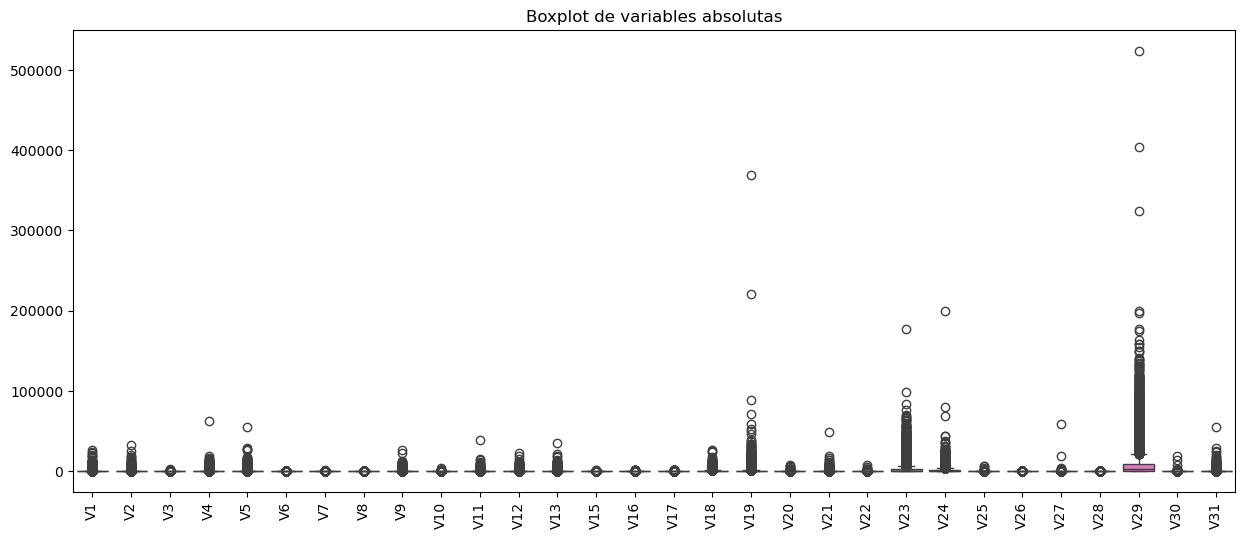

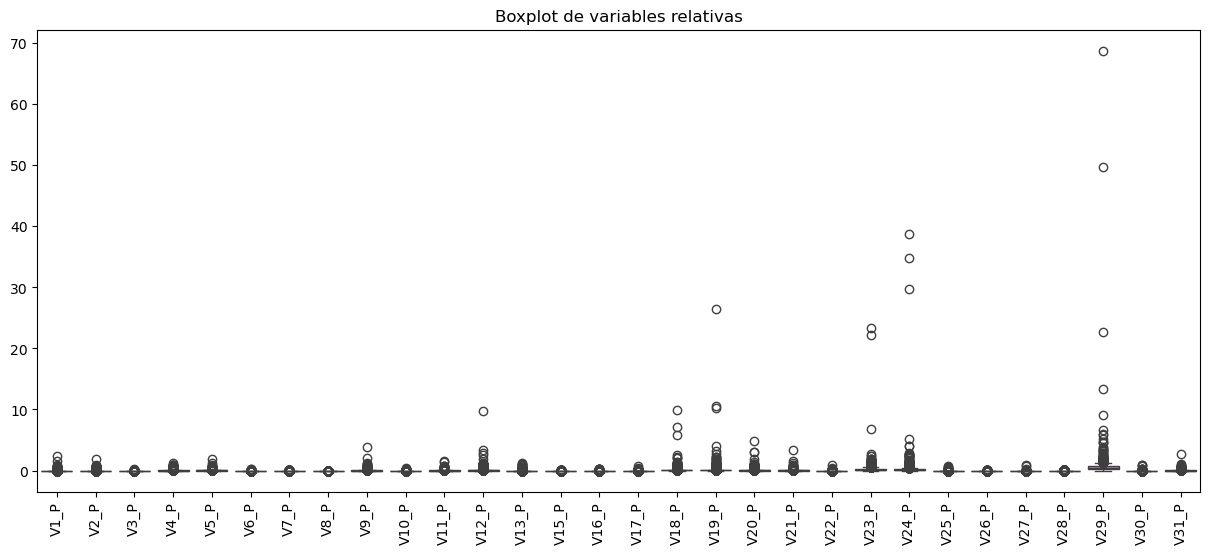

In [ ]:
# Comencemos cargando nuestro conjunto de datos usando la función auxiliar que definimos.
data= leer_dataset()

# Separaremos nuestros datos en columnas absolutas y relativas, y nuestra variable objetivo.
columnas_absolutas=[col for col in data.columns if '_P' not in col and col != 'OBJ' and col != 'VT']
columnas_relativas=[col for col in data.columns if '_P' in col]
y=data['OBJ']  # Variable objetivo
x_abs= data[columnas_absolutas]  # Variables absolutas
x_rel= data[columnas_relativas]  # Variables relativas

# Ahora, dividimos nuestros datos. Es crucial tener conjuntos de entrenamiento y prueba separados.
# Entrenamos nuestro modelo en el conjunto de entrenamiento y luego probamos su rendimiento en el conjunto de prueba no visto.
# 'stratify=y' garantiza que la proporción de nuestras clases objetivo sea la misma en los conjuntos de entrenamiento y prueba
# 'random_state=42' hace que nuestra división sea reproducible.
x_abs_train,x_abs_test,y_abs_train,y_abs_test=train_test_split(x_abs,y,test_size=0.2,stratify=y,random_state=42)
x_rel_train,x_rel_test,y_rel_train,y_rel_test=train_test_split(x_rel,y,test_size=0.2,stratify=y,random_state=42)

# Visualicemos las distribuciones iniciales de nuestras variables con diagramas de caja.
plot_boxplot(data, columnas_absolutas, titulo='Boxplot de variables absolutas')
plot_boxplot(data, columnas_relativas, titulo='Boxplot de variables relativas')

   variable  outliers_count  outliers_percent
0        V1            2334             23.34
1        V2            1863             18.63
2        V3            1708             17.08
3        V4            1593             15.93
4        V5            1417             14.17
5        V6            1313             13.13
6        V7             514              5.14
7        V8             155              1.55
8        V9            1447             14.47
9       V10            1895             18.95
10      V11            1461             14.61
11      V12            1335             13.35
12      V13            2133             21.33
13      V15            1006             10.06
14      V16             996              9.96
15      V17            1309             13.09
16      V18            1163             11.63
17      V19            1360             13.60
18      V20             895              8.95
19      V21            1242             12.42
20      V22            1742       

C:\Users\Nicolas Oporto\AppData\Local\Temp\ipykernel_31016\461012340.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


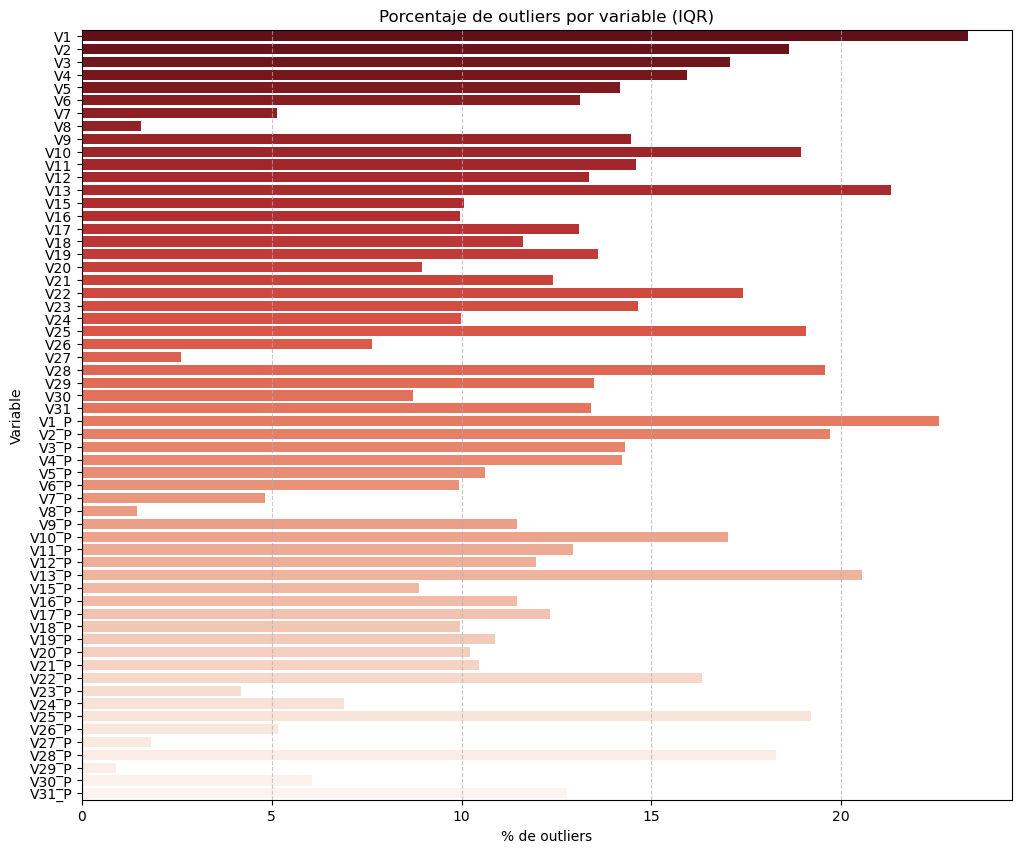

In [12]:
outliers = count_outliers_iqr(data, columnas_absolutas+columnas_relativas)
print(outliers)

plt.figure(figsize=(12,10))
sns.barplot(
    x='outliers_percent',
    y='variable',
    data=outliers,
    palette='Reds_r'
)
plt.xlabel('% de outliers')
plt.ylabel('Variable')
plt.title('Porcentaje de outliers por variable (IQR)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [7]:
outliers = outlier_proportion_by_target(
    df=data,
    columns=columnas_absolutas + columnas_relativas,
    target='OBJ',
    factor=1.5
)

print(outliers)


   variable  outliers_%_target_0  outliers_%_target_1     diff_%
0        V2            15.973445            26.116838  10.143393
1      V2_P            17.206341            26.727759   9.521418
2        V3            14.930226            23.138603   8.208376
3      V3_P            12.437339            19.625811   7.188472
4     V22_P            14.550874            21.344024   6.793151
5        V4            14.252811            20.656739   6.403928
6       V22            15.743124            22.145857   6.402733
7     V28_P            16.691505            22.756777   6.065272
8      V4_P            12.721853            18.518519   5.796665
9       V28            18.086980            23.787705   5.700725
10      V15             8.698008            13.898435   5.200426
11    V15_P             7.587048            12.485682   4.898634
12    V21_P             9.388972            13.440244   4.051273
13      V16             8.914781            12.905689   3.990908
14      V21            11

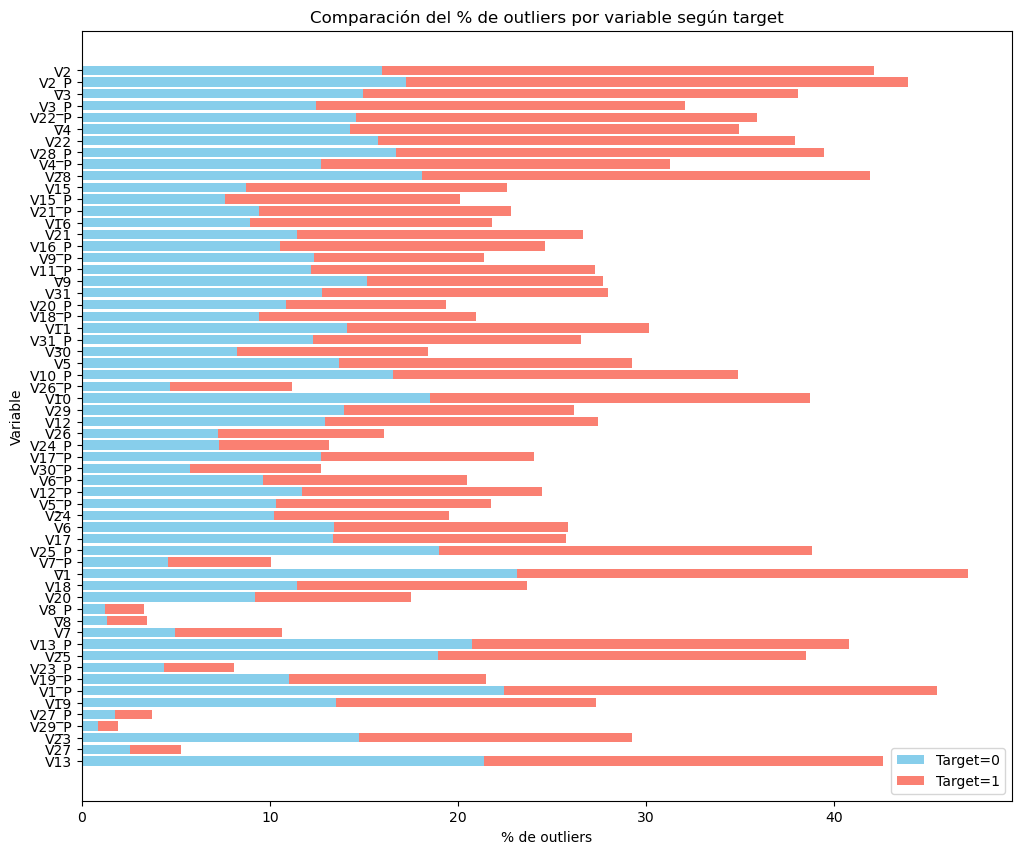

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar por la diferencia descendente
outliers_by_target_sorted = outliers.sort_values(by='diff_%', ascending=False)

# Crear plot
plt.figure(figsize=(12,10))
plt.barh(outliers_by_target_sorted['variable'], 
         outliers_by_target_sorted['outliers_%_target_0'], label='Target=0', color='skyblue')
plt.barh(outliers_by_target_sorted['variable'], 
         outliers_by_target_sorted['outliers_%_target_1'], 
         left=outliers_by_target_sorted['outliers_%_target_0'], 
         label='Target=1', color='salmon')

plt.xlabel('% de outliers')
plt.ylabel('Variable')
plt.title('Comparación del % de outliers por variable según target')
plt.legend()
plt.gca().invert_yaxis()
plt.show()


No se limpiaran los outliers dado que estan presentes en gran medida en todo el dataset en consecuencia tendriamos mucha perdida de informacion, veremos como se comporta con modelos mas complejos y  en ultimo caso intentar con tratamiento de outliers para ver si el modelo se comporta mejor.

# Limpieza de outliers solo en train set

In [71]:
x_abs_train_cap,limits_cap=cap_outliers_iqr(x_abs_train, x_abs_train.columns, factor=1.5)
x_abs_test_cap=apply_caps(x_abs_test, limits_cap)
x_rel_train_cap=recalculate_relative_variables(x_abs_train_cap,columnas_absolutas, relative_suffix='_P', total_column='VT')
x_rel_test_cap=recalculate_relative_variables(x_abs_test_cap,columnas_absolutas, relative_suffix='_P', total_column='VT')

 # Feature selection (test chi² y punto biserial)

In [ ]:
# ==============================================================
# 1️⃣ Crear copia temporal del dataframe para el análisis Chi²
# ==============================================================

# En esta sección, realizaremos la selección de características.
# Utilizaremos la prueba de chi-cuadrado y la correlación biserial puntual para identificar las variables más prometedoras para nuestro modelo.

# Primero, crearemos una copia temporal de nuestros datos para este análisis.
df_temp = data.copy()
aplicaron_log = []

for col in columnas_absolutas + columnas_relativas:
    # Winsorizing al 1% y 99%
    q01 = df_temp[col].quantile(0.01)
    q99 = df_temp[col].quantile(0.99)
    df_temp[col] = df_temp[col].clip(lower=q01, upper=q99)
    
    # Log si todos los valores son positivos después del clip
    if (df_temp[col] > 0).all():
        df_temp[col] = np.log(df_temp[col])
        aplicaron_log.append(col)

print("✅ Winsorizing aplicado (1%-99%) en todas las variables.")
print("✅ Log aplicado en las siguientes variables (solo si >0):")
print(aplicaron_log)

# ==============================================================
# 2️⃣ Exploración: verificar al menos 2 bins para el Chi²
# ==============================================================

variables_candidatas = columnas_absolutas + columnas_relativas

variables_exploratorias = []
excluidas_sin_variacion = []

for col in variables_candidatas:
    try:
        bins = pd.qcut(df_temp[col], q=4, labels=False, duplicates='drop')
        n_bins = bins.nunique()
        if n_bins > 1:
            variables_exploratorias.append(col)
        else:
            excluidas_sin_variacion.append(col)
    except Exception as e:
        excluidas_sin_variacion.append(col)

print("\n❌ Variables excluidas por no tener suficiente variación (solo 1 bin):")
print(excluidas_sin_variacion)

print("\n✅ Variables que pasaron a validación Chi² (≥2 bins):")
print(variables_exploratorias)

✅ Winsorizing aplicado (1%-99%) en todas las variables.
✅ Log aplicado en las siguientes variables (solo si >0):
['V19', 'V24', 'V19_P', 'V24_P']

❌ Variables excluidas por no tener suficiente variación (solo 1 bin):
['V3', 'V7', 'V8', 'V10', 'V15', 'V26', 'V27', 'V28', 'V30', 'V3_P', 'V7_P', 'V8_P', 'V10_P', 'V15_P', 'V26_P', 'V27_P', 'V28_P', 'V30_P']

✅ Variables que pasaron a validación Chi² (≥2 bins):
['V1', 'V2', 'V4', 'V5', 'V6', 'V9', 'V11', 'V12', 'V13', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V29', 'V31', 'V1_P', 'V2_P', 'V4_P', 'V5_P', 'V6_P', 'V9_P', 'V11_P', 'V12_P', 'V13_P', 'V16_P', 'V17_P', 'V18_P', 'V19_P', 'V20_P', 'V21_P', 'V22_P', 'V23_P', 'V24_P', 'V25_P', 'V29_P', 'V31_P']


In [19]:
resultados = []

for col in variables_exploratorias:
    try:
        bins = pd.qcut(df_temp[col], q=4, labels=False, duplicates='drop')
        contingency = pd.crosstab(bins, data['OBJ'])  # importante: con OBJ original
        n_bins = bins.nunique()
        min_cell = contingency.min().min()

        # Frecuencia mínima por celda
        if min_cell < 5:
            resultados.append({
                'Variable': col,
                'Bins': n_bins,
                'Min count': min_cell,
                'Chi2': np.nan,
                'p-value': np.nan,
                'Status': f'Excluida (celda <5)'
            })
            continue

        # Aplicar Chi²
        chi2, p, dof, expected = chi2_contingency(contingency)
        status = 'Significativa' if p < 0.05 else 'No significativa'

        resultados.append({
            'Variable': col,
            'Bins': n_bins,
            'Min count': min_cell,
            'Chi2': chi2,
            'p-value': p,
            'Status': status
        })

    except Exception as e:
        resultados.append({
            'Variable': col,
            'Bins': np.nan,
            'Min count': np.nan,
            'Chi2': np.nan,
            'p-value': np.nan,
            'Status': f'Error: {e}'
        })

# Convertir a DataFrame ordenado
resultados_df = pd.DataFrame(resultados).sort_values(by='p-value', na_position='last')

# Mostrar tabla final
print("🔍 Resumen del test Chi² por variable:")
display(resultados_df)

# Variables seleccionadas para el modelo
variables_finales = resultados_df.loc[resultados_df['Status'] == 'Significativa', 'Variable'].tolist()

print("\n✅ Variables seleccionadas para el modelo final (Chi² significativas):")
print(variables_finales)


🔍 Resumen del test Chi² por variable:


,Variable,Bins,Min count,Chi2,p-value,Status
22,V2_P,3,639,131.531874,2.742941e-29,Significativa
1,V2,3,646,131.075014,3.446849e-29,Significativa
23,V4_P,4,491,133.868456,7.930891e-29,Significativa
9,V16,4,496,127.155888,2.217860e-27,Significativa
2,V4,4,477,123.737516,1.208923e-26,Significativa
35,V21_P,4,492,110.353720,9.208969e-24,Significativa
36,V22_P,3,672,105.085414,1.517024e-23,Significativa
20,V31,4,474,97.963156,4.260000e-21,Significativa
30,V16_P,4,508,96.791492,7.608035e-21,Significativa
14,V21,4,488,92.115505,7.693409e-20,Significativa



✅ Variables seleccionadas para el modelo final (Chi² significativas):
['V2_P', 'V2', 'V4_P', 'V16', 'V4', 'V21_P', 'V22_P', 'V31', 'V16_P', 'V21', 'V22', 'V19', 'V23', 'V31_P', 'V18', 'V6', 'V19_P', 'V5', 'V29', 'V11', 'V5_P', 'V6_P', 'V12', 'V20', 'V11_P', 'V13', 'V24', 'V18_P', 'V9_P', 'V9', 'V23_P', 'V17_P', 'V17', 'V24_P', 'V13_P', 'V29_P', 'V25', 'V25_P', 'V20_P', 'V12_P']


In [20]:
from scipy.stats import pointbiserialr
import numpy as np
import pandas as pd

# Combinar todas las variables (exploratorias que pasaron bins + las que no)
todas_las_variables = variables_exploratorias + excluidas_sin_variacion

# Lista para guardar resultados
resultados_pb_total = []

for col in todas_las_variables:
    try:
        corr, pval = pointbiserialr(data['OBJ'], data[col])
        status = 'Significativa' if pval < 0.05 else 'No significativa'
        
        resultados_pb_total.append({
            'Variable': col,
            'r_pb': corr,
            'p-value': pval,
            'Status': status
        })
    except Exception as e:
        resultados_pb_total.append({
            'Variable': col,
            'r_pb': np.nan,
            'p-value': np.nan,
            'Status': f'Error: {e}'
        })

# Convertir a DataFrame ordenado
resultados_pb_df_total = pd.DataFrame(resultados_pb_total).sort_values(by='p-value', na_position='last')

# Mostrar tabla
print("📊 Resultados del test punto-biserial en todas las variables:")
display(resultados_pb_df_total)


📊 Resultados del test punto-biserial en todas las variables:


,Variable,r_pb,p-value,Status
2,V4,0.057686,7.801350e-09,Significativa
22,V2_P,0.052559,1.449194e-07,Significativa
23,V4_P,0.046250,3.711102e-06,Significativa
11,V18,0.041480,3.335613e-05,Significativa
35,V21_P,0.038599,1.130080e-04,Significativa
1,V2,0.037323,1.891121e-04,Significativa
9,V16,0.035592,3.709608e-04,Significativa
49,V28,0.034582,5.426212e-04,Significativa
14,V21,0.033947,6.857541e-04,Significativa
18,V25,0.032404,1.191660e-03,Significativa


## Comparación del Chi² vs Punto Biserial

En este análisis se evaluó la asociación de cada variable independiente con la variable objetivo (`OBJ`) utilizando dos enfoques complementarios:

- **Test Chi²:** mide independencia entre categorías formadas mediante binning (qcut), adecuado para identificar diferencias en la distribución entre segmentos.
- **Correlación punto biserial:** mide la relación lineal directa entre la variable continua y la variable binaria `OBJ`.

Algunos hallazgos clave del análisis:

    Varias variables resultaron significativas según el test Chi², reflejando que su distribución discreta difiere entre las clases (por ejemplo, `V4`, `V16`, `V22`).  
    Otras variables mostraron significancia solo bajo el punto biserial (por ejemplo `V15`, `V28`), indicando que, aunque no presentan diferencias claras por bins, sí mantienen una tendencia lineal con `OBJ`.

Además, el análisis evidenció que:

- Las variables excluidas del Chi² (por no poder formar al menos 2 bins) igualmente fueron evaluadas mediante punto biserial, lo que permitió rescatar posibles relaciones lineales que de otra forma hubieran quedado descartadas.
- La comparación lado a lado permite validar la robustez de cada variable, identificando cuáles son significativas en ambos enfoques, y cuáles solo bajo una perspectiva.

Este análisis garantiza que la selección final de variables para el modelo no dependa de un único criterio estadístico, sino de una visión integral, maximizando la capacidad explicativa del conjunto de datos.

In [21]:
# -----------------------------------------------------
# 1️⃣ Preparamos el DataFrame del Chi²
# -----------------------------------------------------
df_chi = resultados_df[['Variable', 'Status', 'p-value']].rename(
    columns={'Status': 'Chi² Status', 'p-value': 'Chi² p-value'}
)

# -----------------------------------------------------
# 2️⃣ Preparamos el DataFrame del punto biserial
# -----------------------------------------------------
df_pb = resultados_pb_df_total[['Variable', 'Status', 'p-value']].rename(
    columns={'Status': 'PuntoBiserial Status', 'p-value': 'PuntoBiserial p-value'}
)

# -----------------------------------------------------
# 3️⃣ Hacemos el merge
# -----------------------------------------------------
df_comparativo = pd.merge(df_chi, df_pb, on='Variable', how='outer')

# Ordenar por nombre de variable o por Chi² p-value
df_comparativo.sort_values(by='Variable', inplace=True)

df_comparativo['Chi² Status'] = df_comparativo['Chi² Status'].fillna('No evaluada (1 bin o excluida)')


# -----------------------------------------------------
# 4️⃣ Mostrar tabla final
# -----------------------------------------------------
print("📊 Comparación del resultado del Chi² vs Punto Biserial:")
display(df_comparativo)


📊 Comparación del resultado del Chi² vs Punto Biserial:


,Variable,Chi² Status,Chi² p-value,PuntoBiserial Status,PuntoBiserial p-value
0,V1,No significativa,4.384827e-01,No significativa,2.394487e-01
1,V10,No evaluada (1 bin o excluida),NaN,No significativa,9.363011e-01
2,V10_P,No evaluada (1 bin o excluida),NaN,No significativa,3.314742e-01
3,V11,Significativa,4.935136e-12,No significativa,9.998242e-02
4,V11_P,Significativa,2.050967e-08,No significativa,1.507780e-01
5,V12,Significativa,7.787469e-11,No significativa,1.367638e-01
6,V12_P,Significativa,3.965901e-02,No significativa,2.189518e-01
7,V13,Significativa,4.483070e-08,No significativa,1.128766e-01
8,V13_P,Significativa,3.606376e-05,No significativa,1.370947e-01
9,V15,No evaluada (1 bin o excluida),NaN,Significativa,2.175373e-02


## Criterio final para selección de variables

Para la etapa de selección de variables, se aplicaron dos enfoques complementarios:

- **Test Chi²:** evalúa la independencia entre la variable categorizada (mediante binning) y la variable objetivo binaria `OBJ`.
- **Correlación punto biserial:** mide la relación lineal directa entre la variable continua y `OBJ`.

El criterio adoptado para conservar variables en el modelo fue **incluir todas aquellas que resultaron significativas en al menos uno de los dos tests**.  
De este modo, se garantiza no descartar variables que puedan aportar capacidad explicativa, ya sea por evidenciar una relación segmentada (detectada por Chi²) o una tendencia lineal (detectada por punto biserial).

Solo se eliminaron las variables que **no mostraron significancia estadística en ninguno de los dos enfoques**, asegurando así un modelo final con el máximo potencial informativo.

In [22]:
# Variables que NO pasaron ninguno de los dos tests:
# es decir, no significativas en Chi² y no significativas en punto biserial
no_significativas_ninguno = df_comparativo[
    ((df_comparativo['Chi² Status'] != 'Significativa') & 
     (df_comparativo['PuntoBiserial Status'] != 'Significativa'))
]['Variable'].tolist()

# Separar en ABS y REL
candidatas_quitar_abs = [v for v in no_significativas_ninguno if v in columnas_absolutas]
candidatas_quitar_rel = [v for v in no_significativas_ninguno if v in columnas_relativas]

print("Variables ABSOLUTAS candidatas a eliminar (no significativas en ninguno de los dos tests):")
print(candidatas_quitar_abs)

print("\nVariables PROPORCIONALES candidatas a eliminar (no significativas en ninguno de los dos tests):")
print(candidatas_quitar_rel)


Variables ABSOLUTAS candidatas a eliminar (no significativas en ninguno de los dos tests):
['V1', 'V10', 'V27', 'V30', 'V7', 'V8']

Variables PROPORCIONALES candidatas a eliminar (no significativas en ninguno de los dos tests):
['V10_P', 'V15_P', 'V1_P', 'V26_P', 'V27_P', 'V28_P', 'V30_P', 'V3_P', 'V7_P', 'V8_P']


## Análisis de multicolinealidad en variables absolutas

Para garantizar la estabilidad y la interpretabilidad del modelo, se evaluó la multicolinealidad entre las variables absolutas mediante la matriz de correlación de Pearson.

- Se construyó una matriz de correlación absoluta (`corr().abs()`), extrayendo únicamente el triángulo superior para evitar duplicados.
- Se revisaron todas las parejas de variables, utilizando un umbral de **0.90** para identificar posibles redundancias.

El análisis evidenció que **no existieron pares de variables con correlación superior a 0.90**, por lo que no fue necesario eliminar ninguna variable en esta etapa.  
Esto confirma que el conjunto de variables absolutas no presenta problemas de colinealidad alta y puede ser utilizado en el modelo sin riesgo de inestabilidad numérica asociada a variables redundantes.

In [25]:
# ============================================
# BLOQUE PARA ABSOLUTOS
# ============================================
# Calcular matriz de correlación absoluta
corr_matrix_abs = x_abs.corr().abs()

# Extraer triángulo superior para evitar duplicados
upper_abs = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# Buscar variables con correlación mayor a 0.90
to_drop_abs_corr = [column for column in upper_abs.columns if any(upper_abs[column] > 0.90)]

print("Variables ABSOLUTAS a eliminar por alta correlación (>0.90):", to_drop_abs_corr)

# Eliminar del dataset
X_abs_reduced = x_abs.drop(columns=to_drop_abs_corr)

print("Shape original ABS:", x_abs.shape)
print("Shape reducido ABS:", X_abs_reduced.shape)


# ============================================
# BLOQUE PARA RELATIVOS
# ============================================
# Calcular matriz de correlación
corr_matrix_p = x_rel.corr().abs()

# Triángulo superior
upper_p = corr_matrix_p.where(np.triu(np.ones(corr_matrix_p.shape), k=1).astype(bool))

# Buscar variables con correlación mayor a 0.90
to_drop_p_corr = [column for column in upper_p.columns if any(upper_p[column] > 0.90)]

print("Variables PROPORCIONALES a eliminar por alta correlación (>0.90):", to_drop_p_corr)

# Eliminar del dataset
X_p_reduced = x_rel.drop(columns=to_drop_p_corr)

print("Shape original PROP:", x_rel.shape)
print("Shape reducido PROP:", X_p_reduced.shape)

Variables ABSOLUTAS a eliminar por alta correlación (>0.90): []
Shape original ABS: (10000, 30)
Shape reducido ABS: (10000, 30)
Variables PROPORCIONALES a eliminar por alta correlación (>0.90): []
Shape original PROP: (10000, 30)
Shape reducido PROP: (10000, 30)


In [13]:
import numpy as np
X_abs = df[columnas_absolutas]
X_p = df[columnas_relativas]
# ============================================
# BLOQUE PARA ABSOLUTOS
# ============================================
# Calcular matriz de correlación absoluta
corr_matrix_abs = X_abs.corr().abs()

# Extraer triángulo superior para evitar duplicados
upper_abs = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# Buscar variables con correlación mayor a 0.90
to_drop_abs_corr = [column for column in upper_abs.columns if any(upper_abs[column] > 0.90)]

print("Variables ABSOLUTAS a eliminar por alta correlación (>0.90):", to_drop_abs_corr)

# Eliminar del dataset
X_abs_reduced = X_abs.drop(columns=to_drop_abs_corr)

print("Shape original ABS:", X_abs.shape)
print("Shape reducido ABS:", X_abs_reduced.shape)

# ============================================
# BLOQUE PARA RELATIVOS
# ============================================
# Calcular matriz de correlación
corr_matrix_p = X_p.corr().abs()

# Triángulo superior
upper_p = corr_matrix_p.where(np.triu(np.ones(corr_matrix_p.shape), k=1).astype(bool))

# Buscar variables con correlación mayor a 0.90
to_drop_p_corr = [column for column in upper_p.columns if any(upper_p[column] > 0.90)]

print("Variables PROPORCIONALES a eliminar por alta correlación (>0.90):", to_drop_p_corr)

# Eliminar del dataset
X_p_reduced = X_p.drop(columns=to_drop_p_corr)

print("Shape original PROP:", X_p.shape)
print("Shape reducido PROP:", X_p_reduced.shape)


Variables ABSOLUTAS a eliminar por alta correlación (>0.90): []
Shape original ABS: (10000, 30)
Shape reducido ABS: (10000, 30)
Variables PROPORCIONALES a eliminar por alta correlación (>0.90): []
Shape original PROP: (10000, 30)
Shape reducido PROP: (10000, 30)


# Declarar variables con las que se va trabajar

In [26]:
# =====================================
# LIBRERÍAS BÁSICAS
# =====================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# =====================================
# DEFINIR VARIABLES SEGÚN TU DATA
# columnas_absolutas y columnas_relativas deben estar ya definidos:
# Ejemplo:
# columnas_absolutas = ['V1', 'V2', ..., 'V30']
# columnas_relativas = ['V1_P', 'V2_P', ..., 'V30_P']
# =====================================
y=data['OBJ']  # Variable objetivo
x= data[columnas_absolutas + columnas_relativas]
x_trained,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)  # Todas las variables
# =====================================
# DATA ABSOLUTA
# =====================================
# DATA ORIGINAL
X_abs = data[columnas_absolutas]

# DATA FILTRADA (sin variables no significativas ni altamente correlacionadas)
X_abs_filtered = X_abs.drop(columns=list(set(candidatas_quitar_abs + to_drop_abs_corr)))

# Dividir en train/test
X_abs_train, X_abs_test, y_abs_train, y_abs_test = train_test_split(
    X_abs, y, test_size=0.2, stratify=y, random_state=42
)
X_abs_f_train, X_abs_f_test, y_abs_f_train, y_abs_f_test = train_test_split(
    X_abs_filtered, y, test_size=0.2, stratify=y, random_state=42
)

# =====================================
# DATA RELATIVA
# =====================================
# DATA ORIGINAL
X_p = data[columnas_relativas]

# DATA FILTRADA
X_p_filtered = X_p.drop(columns=list(set(candidatas_quitar_rel + to_drop_p_corr)))

# Dividir en train/test
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p, y, test_size=0.2, stratify=y, random_state=42
)
X_p_f_train, X_p_f_test, y_p_f_train, y_p_f_test = train_test_split(
    X_p_filtered, y, test_size=0.2, stratify=y, random_state=42
)


In [32]:
y=data['OBJ']  # Variable objetivo
x= data[columnas_absolutas + columnas_relativas]
x_abs= data[columnas_absolutas]
x_abs_filtered= data[columnas_absolutas].drop(columns=list(set(candidatas_quitar_abs + to_drop_abs_corr)))
x_rel= data[columnas_relativas]
x_rel_filtered= data[columnas_relativas].drop(columns=list(set(candidatas_quitar_rel + to_drop_p_corr)))

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x_rel_filtered, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# Random Forest

Fitting 5 folds for each of 4 candidates, totalling 20 fits
              precision    recall  f1-score   support

           0       0.82      0.45      0.58      1476
           1       0.31      0.72      0.44       524

    accuracy                           0.52      2000
   macro avg       0.57      0.58      0.51      2000
weighted avg       0.68      0.52      0.54      2000



,Random Forest
Score,0.517000
Accuracy,0.517000
Precision,0.314908
Recall,0.717557
F1,0.437718


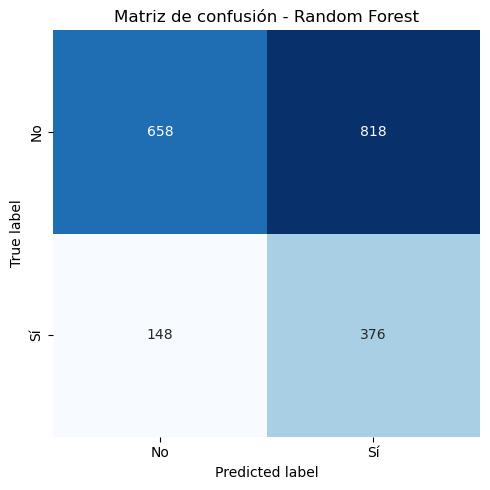

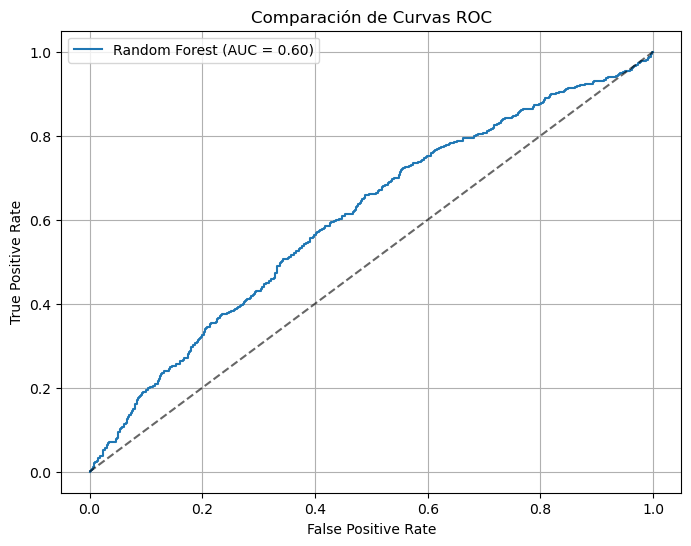

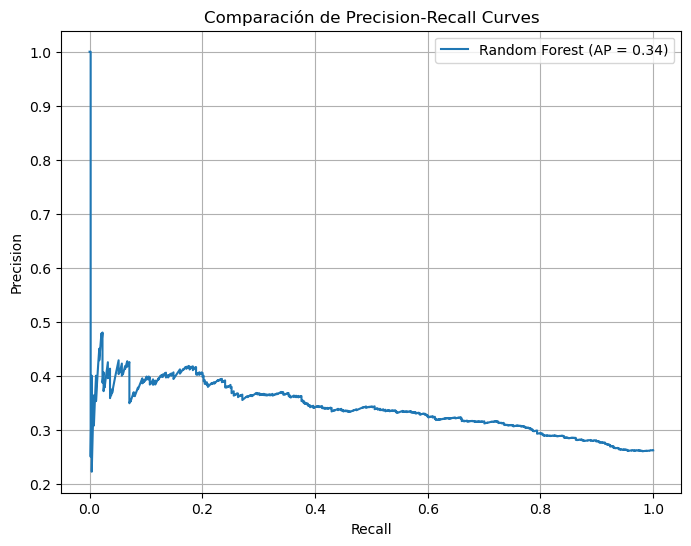

In [ ]:
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from sklearn.model_selection import GridSearchCV

# --- Configuración del pipeline de Machine Learning ---

# Un pipeline es una excelente manera de encadenar varios pasos. 
# Garantiza que apliquemos las mismas transformaciones a nuestros datos de forma consistente, tanto durante el entrenamiento como durante las pruebas.
pipe_rf = Pipeline([
    # Paso 1: Escalado de los datos. QuantileTransformer es una buena opción para datos con valores atípicos.
    # Establecemos output_distribution en 'normal', ya que suele funcionar bien con muchos modelos.
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    # Paso 2: Gestión del desequilibrio de clases. SMOTEENN es una técnica sofisticada que puede
    # mejorar significativamente el rendimiento del modelo en conjuntos de datos desequilibrados.
    ('sampler', SMOTEENN()),
    # Paso 3: Nuestro modelo de clasificación. RandomForest es una opción robusta y de alto rendimiento.
    # 'class_weight='balanced'' es otra forma de gestionar el desequilibrio de clases.
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# --- Configuración de la búsqueda en Grid para el ajuste de hiperparámetros ---
# Vamos a usar GridSearchCV para encontrar la mejor combinación de hiperparámetros para nuestro modelo.
# Este es un paso crucial para optimizar el rendimiento del modelo.
# Estamos definiendo los parámetros para probar.
param_grid_rf = {
    'model__n_estimators': [100, 200], # ¿Cuántos árboles debería haber en nuestro bosque?
    'model__max_depth': [10, 20], # ¿Cuál es la profundidad máxima de cada árbol?
    'model__min_samples_split': [5], # ¿Cuál es el número mínimo de muestras necesarias para dividir un nodo?
    'model__min_samples_leaf': [3] # ¿Cuál es el número mínimo de muestras necesarias en un nodo hoja?
}

# --- Ejecutando la búsqueda en cuadrícula ---
# 'cv=5' significa que estamos usando una validación cruzada quíntuple, una práctica estándar.
# 'scoring='balanced_accuracy'' es una buena métrica para conjuntos de datos desequilibrados.
grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1, # Usa todos los núcleos de CPU disponibles para acelerar el proceso.
    verbose=2 # Esto imprimirá actualizaciones de progreso.
)

# Entrenamiento del modelo
grid_rf.fit(X_train, y_train)

# Tomaremos el mejor modelo encontrado por la búsqueda en la Grid.
best_rf = grid_rf.best_estimator_

# Ahora, haremos predicciones en nuestro conjunto de prueba.
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Finalmente, evaluemos el rendimiento de nuestro modelo optimizado.
print(classification_report(y_test, y_pred_rf))
display(evaluate_models({
    'Random Forest': best_rf  
}, X_test, y_test))

# Visualicemos los resultados.
plot_multiple_confusion_matrix(cm_rf,'Matriz de confusión - Random Forest', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_rf],
    labels_list=["Random Forest"],
)
plot_multiple_precision_recall_curves(y_test, {'Random Forest': y_proba_rf})



Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros encontrados:
{'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100, 'scaler__n_quantiles': 1000, 'scaler__output_distribution': 'normal'}
              precision    recall  f1-score   support

           0       0.81      0.48      0.60      1476
           1       0.32      0.67      0.43       524

    accuracy                           0.53      2000
   macro avg       0.56      0.58      0.52      2000
weighted avg       0.68      0.53      0.56      2000



,Random Forest
Score,0.532500
Accuracy,0.532500
Precision,0.315695
Recall,0.671756
F1,0.429530


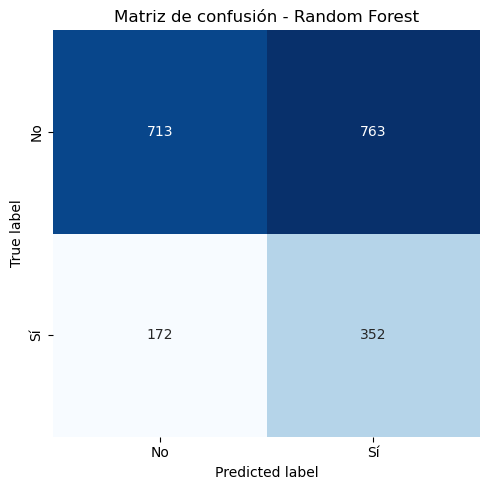

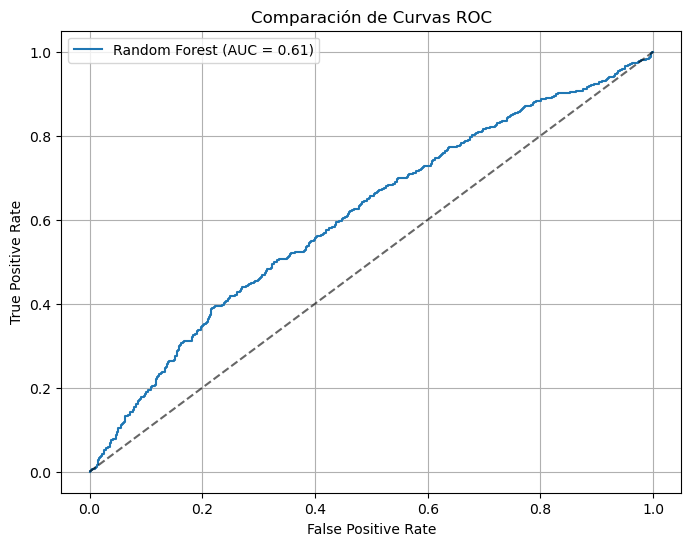

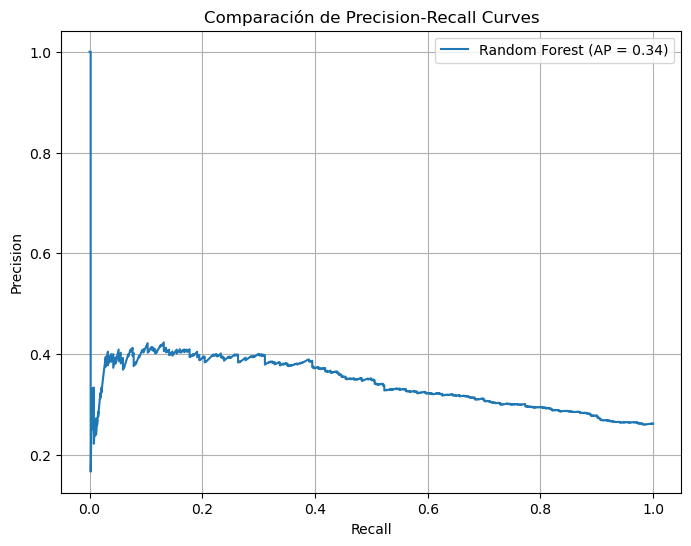

In [ ]:
# Probando diferentes scalers
pipe_rf = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Grid RF
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [3],
    'scaler__n_quantiles': [1000, 2000,3000],
    'scaler__output_distribution': ['normal', 'uniform']
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Mejores parámetros encontrados:")
print(grid_rf.best_params_)
print(classification_report(y_test, y_pred_rf))
display(evaluate_models({
    'Random Forest': best_rf  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_rf,'Matriz de confusión - Random Forest', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_rf],
    labels_list=["Random Forest"],
)
plot_multiple_precision_recall_curves(y_test, {'Random Forest': y_proba_rf})

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros encontrados:
{'model__max_depth': 20, 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 200, 'sampler': SMOTEENN()}
              precision    recall  f1-score   support

           0       0.81      0.46      0.59      1476
           1       0.32      0.70      0.44       524

    accuracy                           0.52      2000
   macro avg       0.57      0.58      0.51      2000
weighted avg       0.68      0.52      0.55      2000



,Random Forest
Score,0.524000
Accuracy,0.524000
Precision,0.316467
Recall,0.704198
F1,0.436686


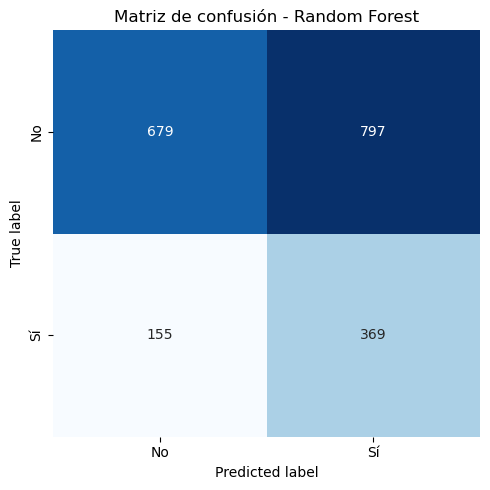

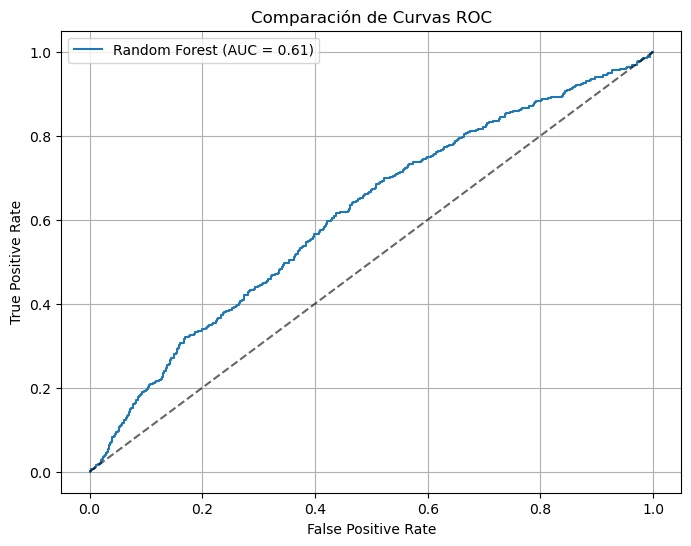

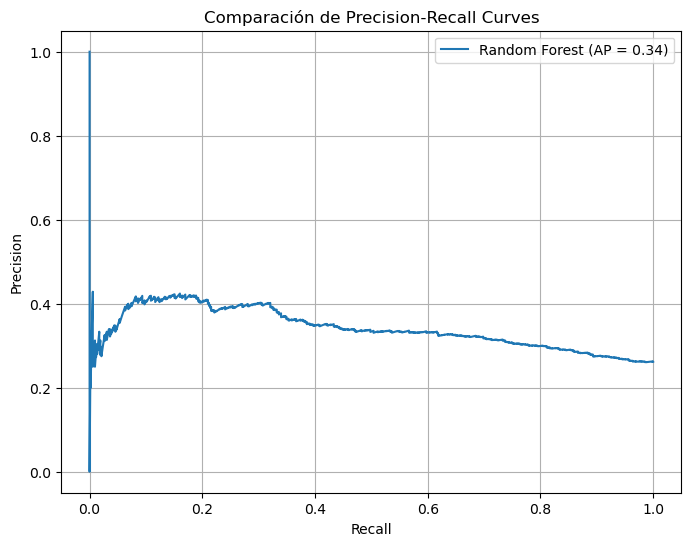

In [129]:
# Probando diferentes samplers

pipe_rf = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Grid RF
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [3],
    'sampler': [SMOTEENN(),SMOTE(), ADASYN(), SMOTETomek(), None]

}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Mejores parámetros encontrados:")
print(grid_rf.best_params_)
print(classification_report(y_test, y_pred_rf))
display(evaluate_models({
    'Random Forest': best_rf  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_rf,'Matriz de confusión - Random Forest', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_rf],
    labels_list=["Random Forest"],
)
plot_multiple_precision_recall_curves(y_test, {'Random Forest': y_proba_rf})

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros encontrados:
{'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100, 'sampler': SMOTEENN(enn=EditedNearestNeighbours(),
         smote=SMOTE(k_neighbors=2, random_state=42, sampling_strategy=0.5))}
              precision    recall  f1-score   support

           0       0.81      0.52      0.63      1476
           1       0.32      0.65      0.43       524

    accuracy                           0.55      2000
   macro avg       0.57      0.58      0.53      2000
weighted avg       0.68      0.55      0.58      2000



,Random Forest
Score,0.554500
Accuracy,0.554500
Precision,0.324737
Recall,0.648855
F1,0.432845


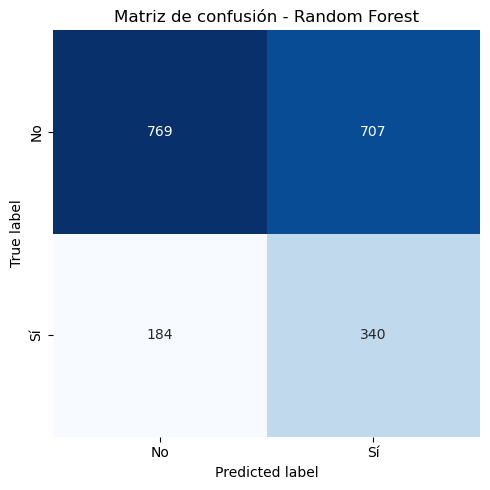

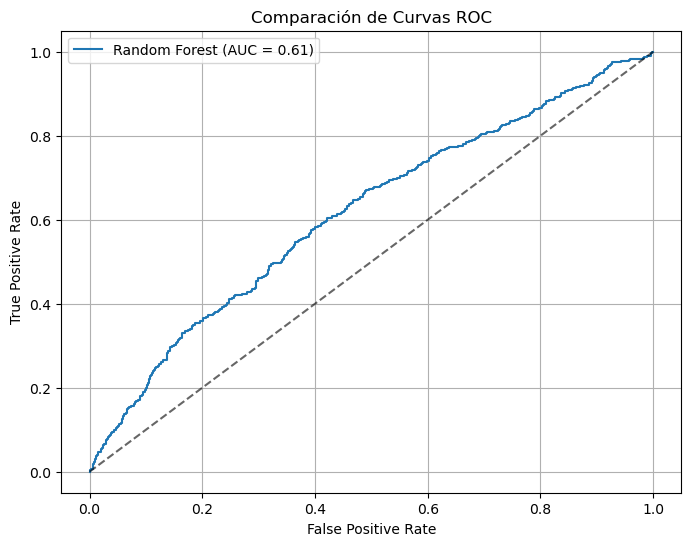

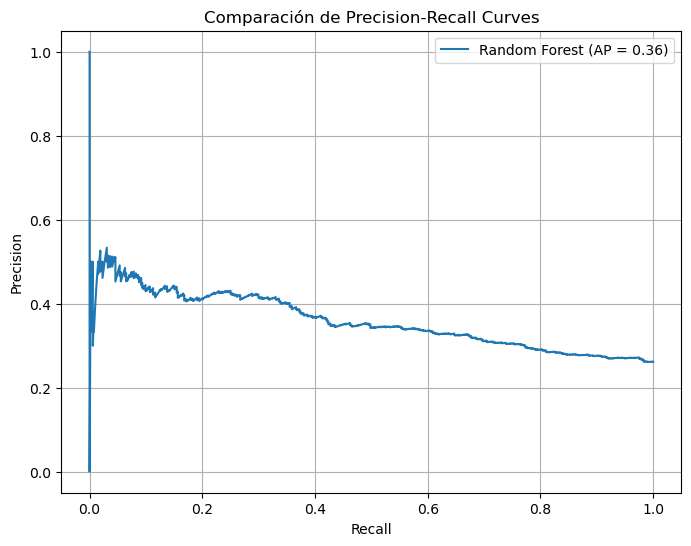

In [131]:
# ajustando SMOTENN
from imblearn.under_sampling import EditedNearestNeighbours
pipe_rf = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Grid RF
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [3],
    'sampler': [
        SMOTEENN(smote=SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=42), 
                 enn=EditedNearestNeighbours(n_neighbors=3)),
        SMOTEENN(smote=SMOTE(k_neighbors=3, sampling_strategy=0.7, random_state=42),
                 enn=EditedNearestNeighbours(n_neighbors=3)),
        SMOTEENN(smote=SMOTE(k_neighbors=3, sampling_strategy=0.5, random_state=42),
                 enn=EditedNearestNeighbours(n_neighbors=5)),
        SMOTEENN(smote=SMOTE(k_neighbors=2, sampling_strategy=0.5, random_state=42),
                 enn=EditedNearestNeighbours(n_neighbors=3)),
        SMOTEENN(smote=SMOTE(k_neighbors=2, sampling_strategy=0.3, random_state=42),
                 enn=EditedNearestNeighbours(n_neighbors=5)),
    ]

}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Mejores parámetros encontrados:")
print(grid_rf.best_params_)
print(classification_report(y_test, y_pred_rf))
display(evaluate_models({
    'Random Forest': best_rf  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_rf,'Matriz de confusión - Random Forest', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_rf],
    labels_list=["Random Forest"],
)
plot_multiple_precision_recall_curves(y_test, {'Random Forest': y_proba_rf})

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Mejores parámetros encontrados:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}
              precision    recall  f1-score   support

           0       0.81      0.53      0.64      1476
           1       0.33      0.64      0.43       524

    accuracy                           0.56      2000
   macro avg       0.57      0.59      0.54      2000
weighted avg       0.68      0.56      0.58      2000



,Random Forest
Score,0.558500
Accuracy,0.558500
Precision,0.325897
Recall,0.641221
F1,0.432154


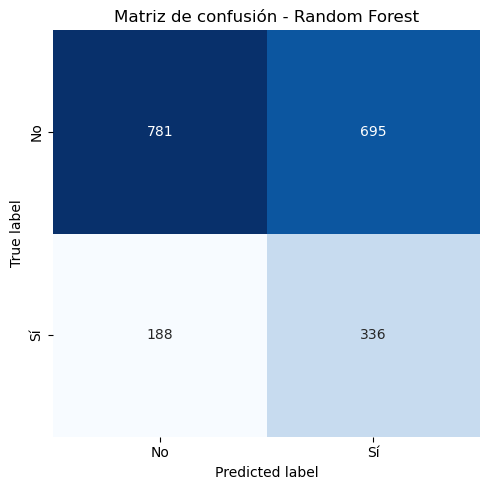

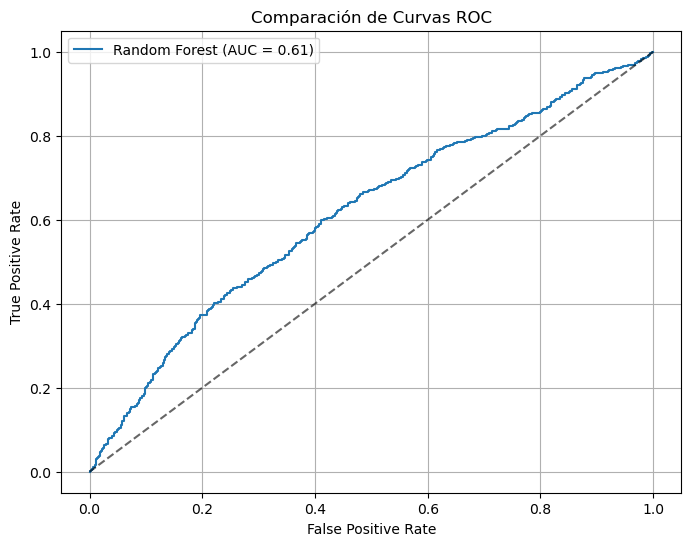

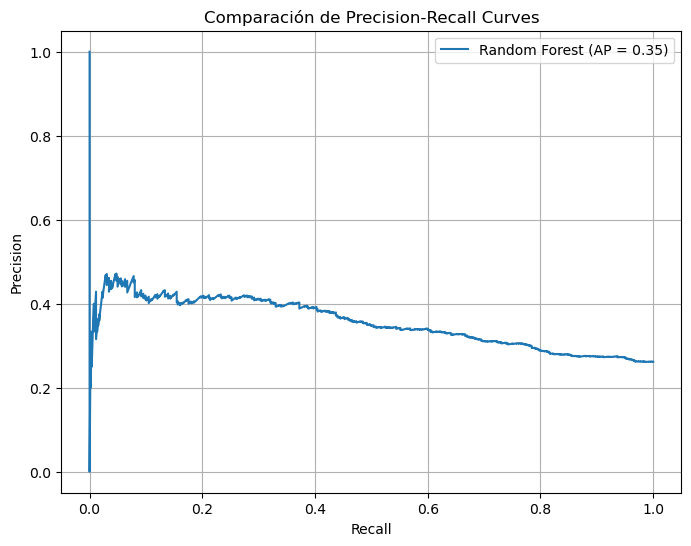

In [142]:
# ajustando parametros del modelo
from imblearn.under_sampling import EditedNearestNeighbours
pipe_rf = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTEENN(enn=EditedNearestNeighbours(),smote=SMOTE(k_neighbors=2, random_state=42, sampling_strategy=0.5))),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Grid RF
param_grid_rf = {
    'model__n_estimators': [100, 200,300],
    'model__max_depth': [8, 10, 12, 15],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [1,2,3,4],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']


 
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Mejores parámetros encontrados:")
print(grid_rf.best_params_)
print(classification_report(y_test, y_pred_rf))
display(evaluate_models({
    'Random Forest': best_rf  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_rf,'Matriz de confusión - Random Forest', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_rf],
    labels_list=["Random Forest"],
)
plot_multiple_precision_recall_curves(y_test, {'Random Forest': y_proba_rf})

modelo ajustado para random forest

# Logistic Regression

Fitting 5 folds for each of 8 candidates, totalling 40 fits
              precision    recall  f1-score   support

           0       0.80      0.44      0.57      1476
           1       0.30      0.69      0.42       524

    accuracy                           0.50      2000
   macro avg       0.55      0.57      0.49      2000
weighted avg       0.67      0.50      0.53      2000



,Logistic Regression
Score,0.504500
Accuracy,0.504500
Precision,0.304603
Recall,0.694656
F1,0.423502


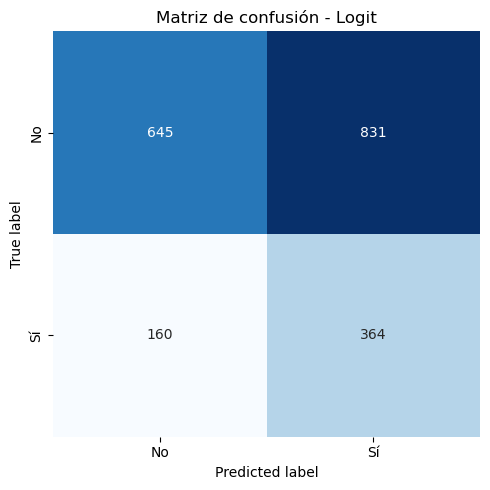

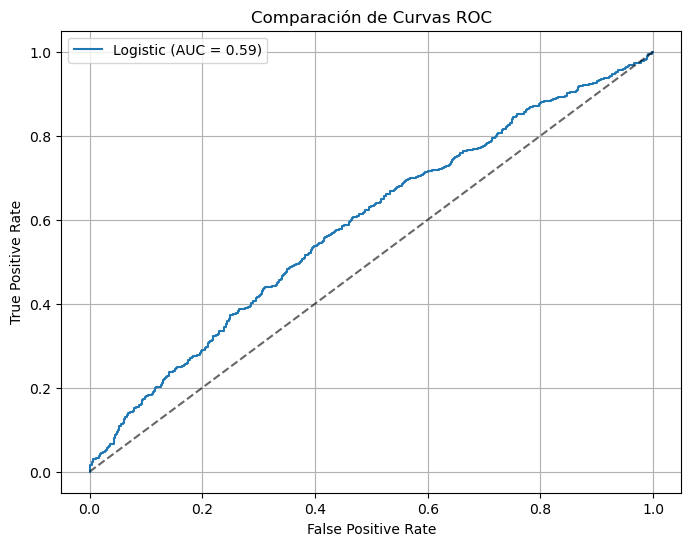

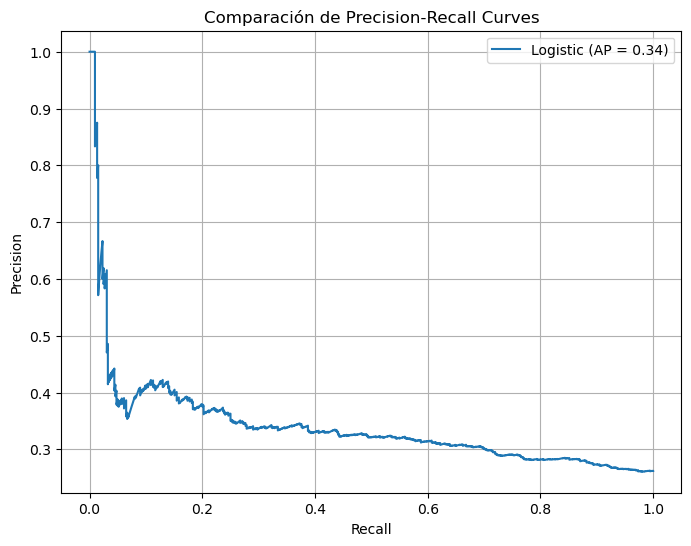

In [ ]:
from sklearn.linear_model import LogisticRegression

pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2']
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]
cm_logit = confusion_matrix(y_test, y_pred_logit)
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})


Fitting 5 folds for each of 8 candidates, totalling 40 fits
              precision    recall  f1-score   support

           0       0.79      0.45      0.57      1476
           1       0.30      0.67      0.42       524

    accuracy                           0.51      2000
   macro avg       0.55      0.56      0.49      2000
weighted avg       0.66      0.51      0.53      2000



,Logistic Regression
Score,0.506000
Accuracy,0.506000
Precision,0.301370
Recall,0.671756
F1,0.416076


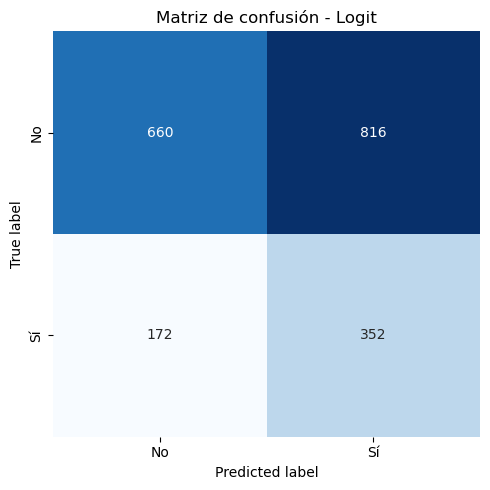

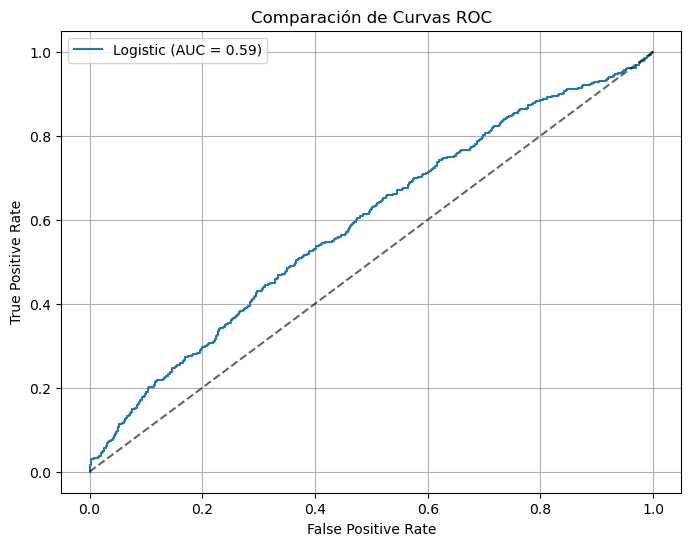

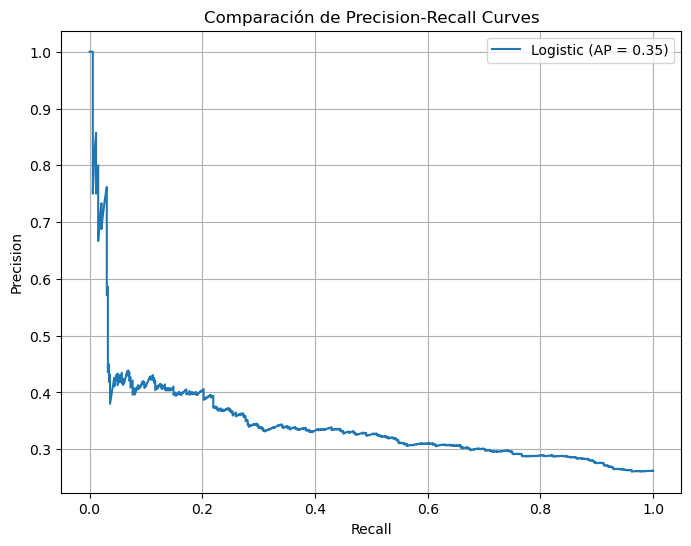

In [112]:
#cambiando a scoring f1
pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2']
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]
cm_logit = confusion_matrix(y_test, y_pred_logit)
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})


Fitting 5 folds for each of 8 candidates, totalling 40 fits
              precision    recall  f1-score   support

           0       0.80      0.44      0.56      1476
           1       0.30      0.69      0.42       524

    accuracy                           0.50      2000
   macro avg       0.55      0.56      0.49      2000
weighted avg       0.67      0.50      0.53      2000



,Logistic Regression
Score,0.502000
Accuracy,0.502000
Precision,0.302013
Recall,0.687023
F1,0.419580


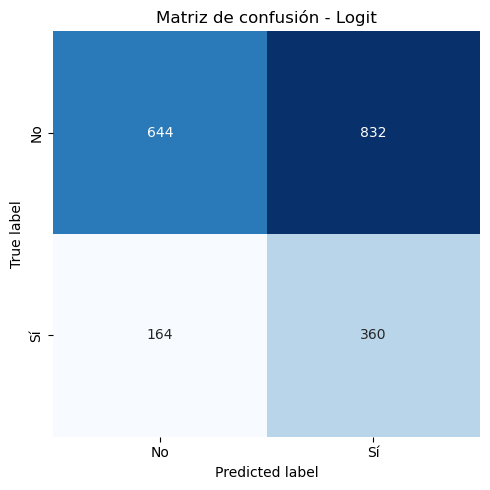

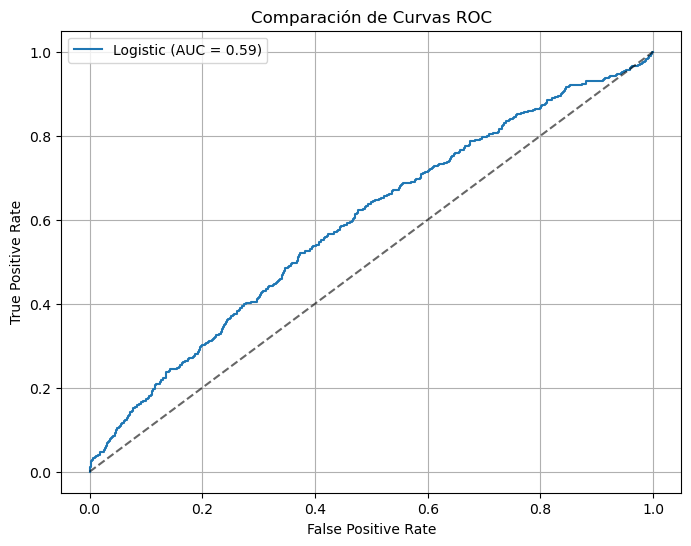

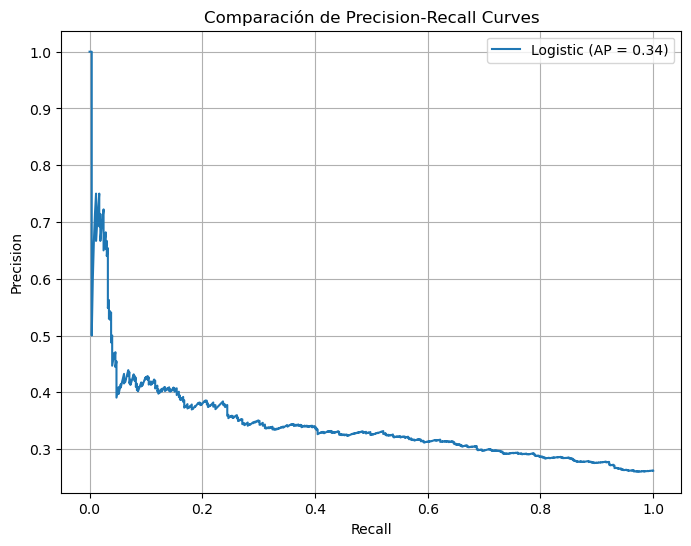

In [113]:
#cambiando a scoring precision
pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2']
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='precision',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]
cm_logit = confusion_matrix(y_test, y_pred_logit)
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})

El scoring no cambió mucho el comportamiento, porque probablemente:

El sampler (SMOTEENN) + class_weight='balanced' fuerza a encontrar la clase minoritaria, inflando recall.

Eso genera muchos falsos positivos, por eso precision baja.

✅ Es decir, el scoring no hizo la diferencia porque el problema está dominado por el sampler y el sesgo del pipeline.

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores parámetros encontrados:
{'model__C': 10, 'model__penalty': 'l2', 'scaler__n_quantiles': 1000, 'scaler__output_distribution': 'uniform'}
              precision    recall  f1-score   support

           0       0.80      0.52      0.63      1476
           1       0.32      0.63      0.42       524

    accuracy                           0.55      2000
   macro avg       0.56      0.58      0.53      2000
weighted avg       0.67      0.55      0.58      2000



,Logistic Regression
Score,0.550000
Accuracy,0.550000
Precision,0.319231
Recall,0.633588
F1,0.424552


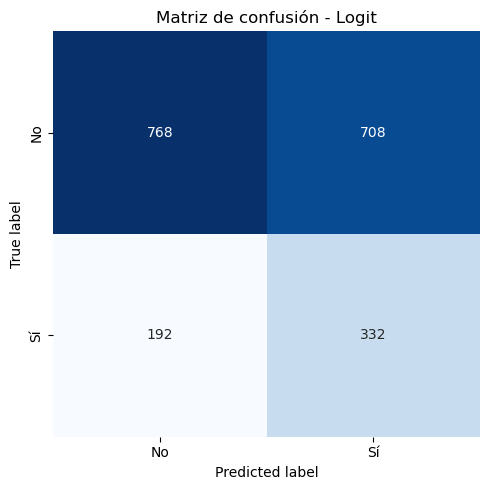

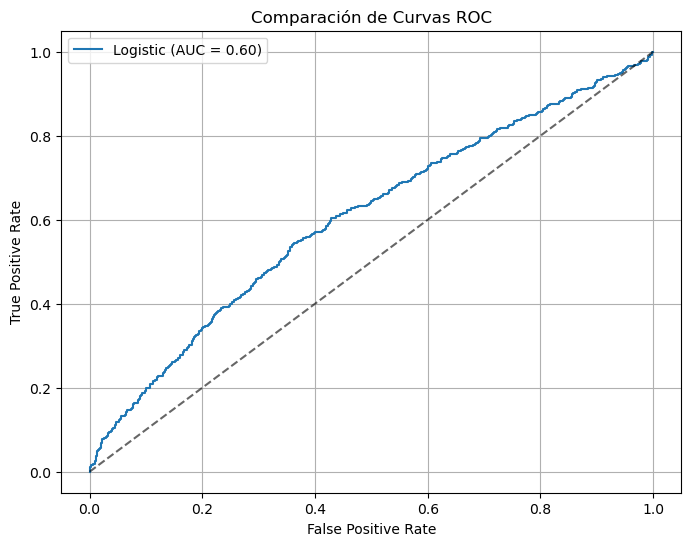

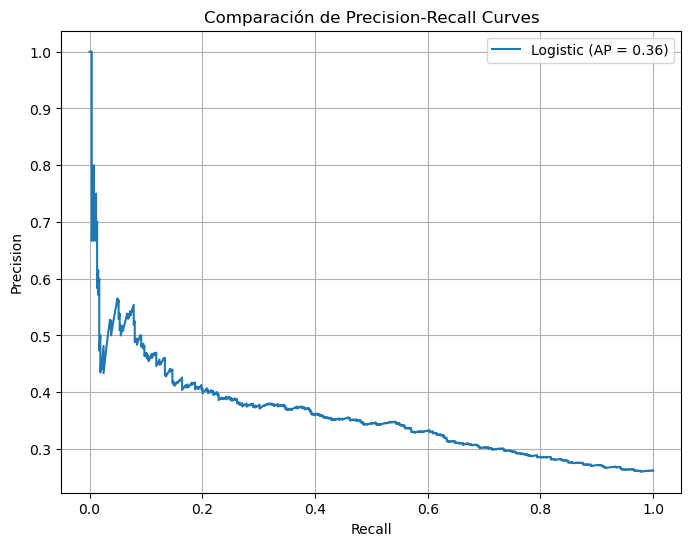

In [117]:
#cambiando el QuantileTransformer grid_search
pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=2000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'scaler__n_quantiles': [1000, 2000, 3000],  # Probar diferentes valores de n_quantiles,
    'scaler__output_distribution': ['normal', 'uniform']  # Probar diferentes distribuciones
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]
cm_logit = confusion_matrix(y_test, y_pred_logit)
print("Mejores parámetros encontrados:")
print(grid_logit.best_params_)
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Mejores parámetros encontrados:
{'model__C': 10, 'model__penalty': 'l2', 'sampler': SMOTETomek()}
              precision    recall  f1-score   support

           0       0.79      0.58      0.67      1476
           1       0.32      0.56      0.41       524

    accuracy                           0.57      2000
   macro avg       0.55      0.57      0.54      2000
weighted avg       0.66      0.57      0.60      2000



,Logistic Regression
Score,0.572500
Accuracy,0.572500
Precision,0.319520
Recall,0.559160
F1,0.406662


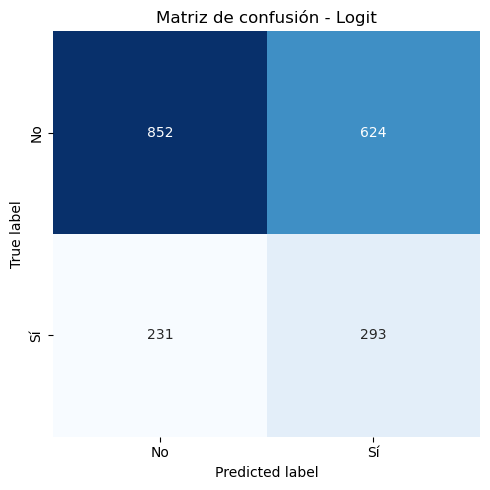

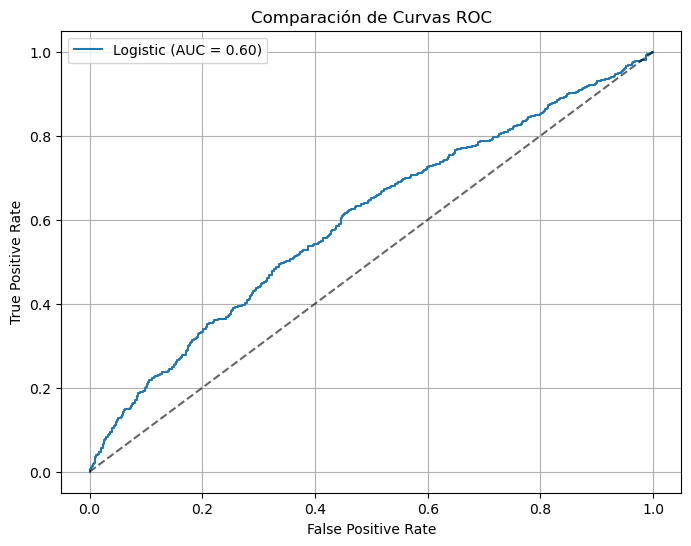

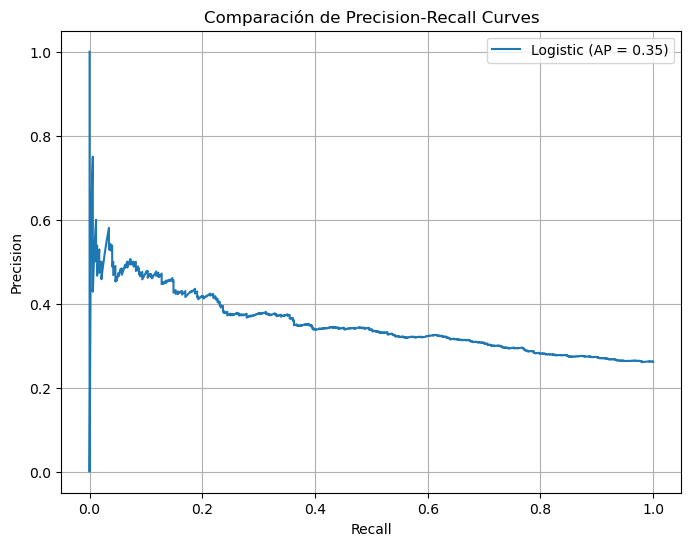

In [132]:
#cambiando el sampler en grid_search
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE, ADASYN 

pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='uniform',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'sampler': [SMOTEENN(),SMOTE(), ADASYN(), SMOTETomek(), None],
 
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]
cm_logit = confusion_matrix(y_test, y_pred_logit)
print("Mejores parámetros encontrados:")
print(grid_logit.best_params_)
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores parámetros encontrados:
{'model__C': 1, 'model__penalty': 'l1', 'sampler': SMOTETomek()}
              precision    recall  f1-score   support

           0       0.79      0.57      0.66      1476
           1       0.32      0.57      0.41       524

    accuracy                           0.57      2000
   macro avg       0.55      0.57      0.54      2000
weighted avg       0.67      0.57      0.60      2000



,Logistic Regression
Score,0.570500
Accuracy,0.570500
Precision,0.320086
Recall,0.568702
F1,0.409622


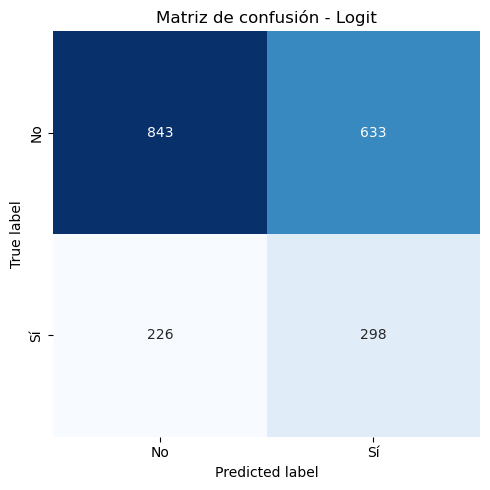

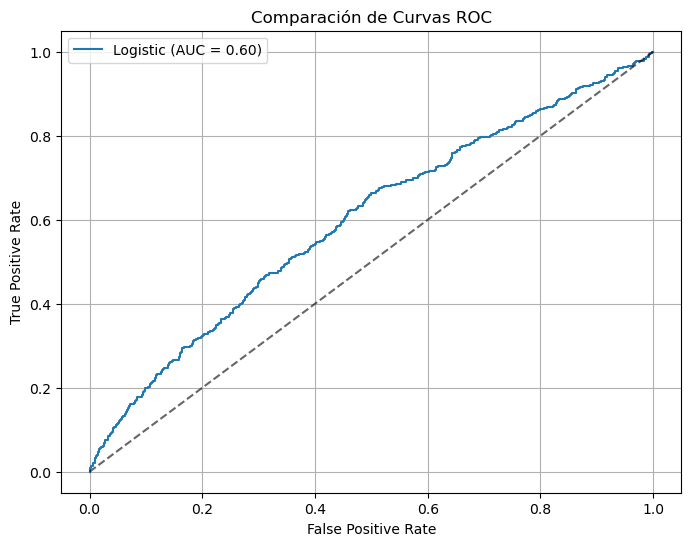

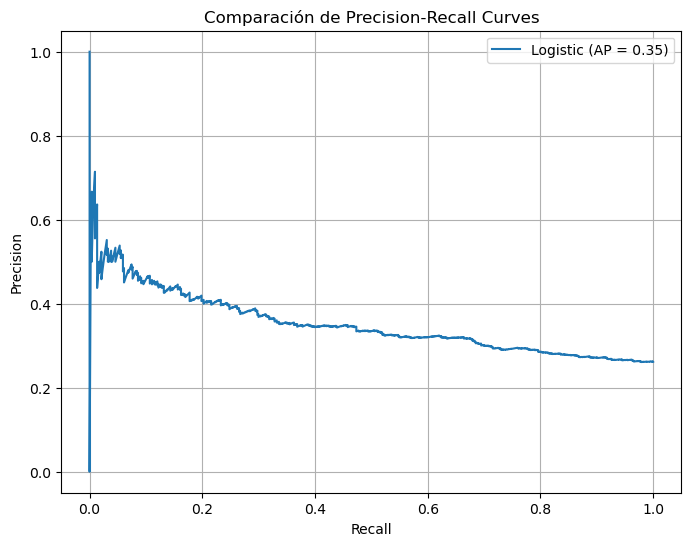

In [ ]:
#cambiando el sampler en grid_search
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE, ADASYN 

pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='uniform',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTETomek()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
        'sampler': [
        SMOTETomek(
            smote=SMOTE(k_neighbors=5, sampling_strategy=1.0, random_state=42)
        ),
        SMOTETomek(
            smote=SMOTE(k_neighbors=3, sampling_strategy=0.7, random_state=42)
        ),
        SMOTETomek(
            smote=SMOTE(k_neighbors=3, sampling_strategy=0.5, random_state=42)
        ),
        SMOTETomek(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.5, random_state=42)
        ),
        SMOTETomek(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.3, random_state=42)
        ),
        SMOTETomek()
    ]
 
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]
cm_logit = confusion_matrix(y_test, y_pred_logit)
print("Mejores parámetros encontrados:")
print(grid_logit.best_params_)
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})

no hubo variacion con las variantes de smotek y termino eligiendo el que estaba por default

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores parámetros encontrados:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'saga'}
              precision    recall  f1-score   support

           0       0.79      0.57      0.66      1476
           1       0.32      0.58      0.41       524

    accuracy                           0.57      2000
   macro avg       0.56      0.57      0.54      2000
weighted avg       0.67      0.57      0.60      2000



,Logistic Regression
Score,0.569500
Accuracy,0.569500
Precision,0.322070
Recall,0.582061
F1,0.414684


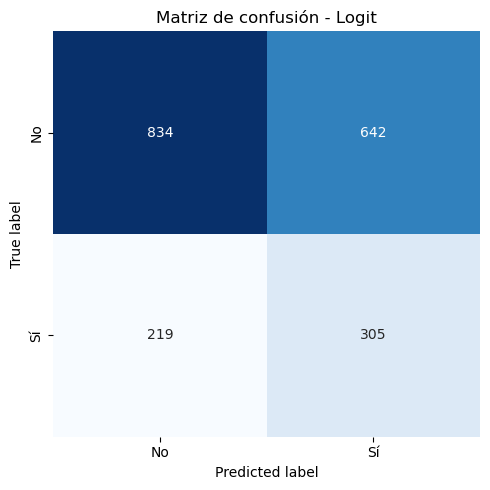

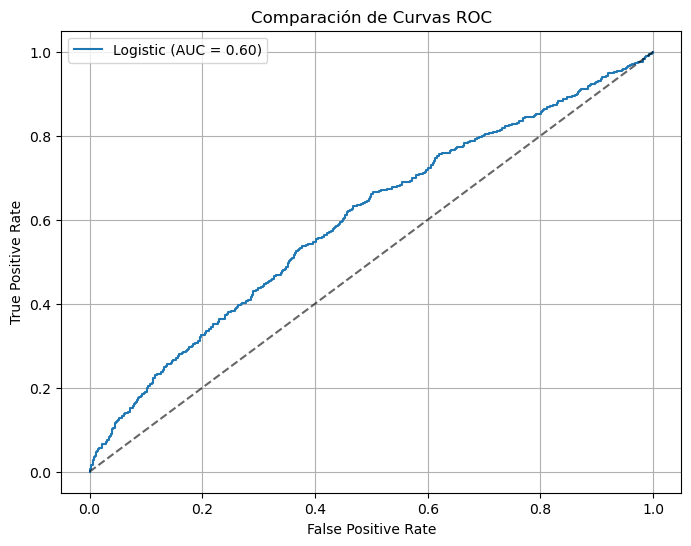

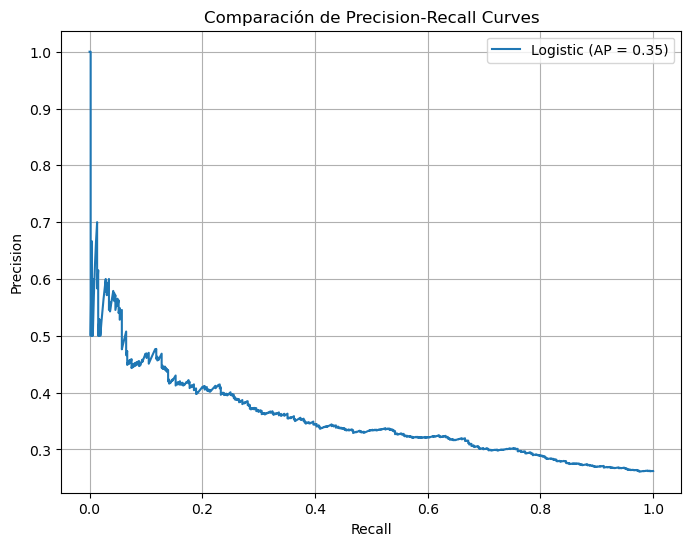

In [136]:
#cambiando el sampler en grid_search
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE, ADASYN 

pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='uniform',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTETomek()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 0.5,1,5, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': [None, 'balanced']

 
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_

y_pred_logit = best_logit.predict(X_test)
y_proba_logit = best_logit.predict_proba(X_test)[:,1]
cm_logit = confusion_matrix(y_test, y_pred_logit)
print("Mejores parámetros encontrados:")
print(grid_logit.best_params_)
print(classification_report(y_test, y_pred_logit))
display(evaluate_models({
    'Logistic Regression': best_logit  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_logit,'Matriz de confusión - Logit', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_logit],
    labels_list=["Logistic"]
)
plot_multiple_precision_recall_curves(y_test, {'Logistic': y_proba_logit})

✔ Este Logistic Regression está completamente tuneado, balanceando bien entre precision y recall, con tu sampler SMOTETomek en la frontera:

No es demasiado agresivo detectando positivos, lo que mantiene FP controlados.

Sigue encontrando ~58% de los positivos reales, con un precision ~0.32 que es consistente en tu problema.

# XGBoost

Fitting 5 folds for each of 1 candidates, totalling 5 fits
              precision    recall  f1-score   support

           0       0.81      0.39      0.53      1476
           1       0.30      0.74      0.43       524

    accuracy                           0.48      2000
   macro avg       0.56      0.57      0.48      2000
weighted avg       0.68      0.48      0.50      2000



,XGBoost
Score,0.484000
Accuracy,0.484000
Precision,0.302181
Recall,0.740458
F1,0.429204


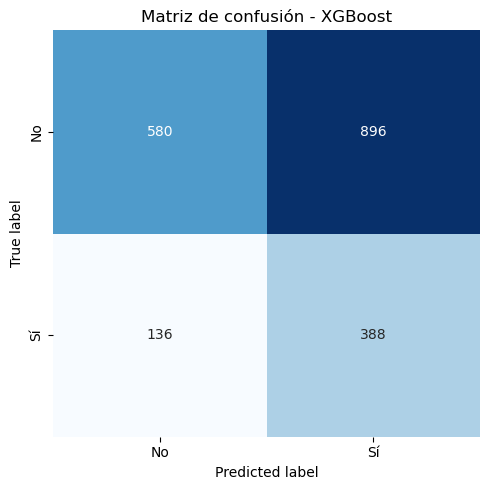

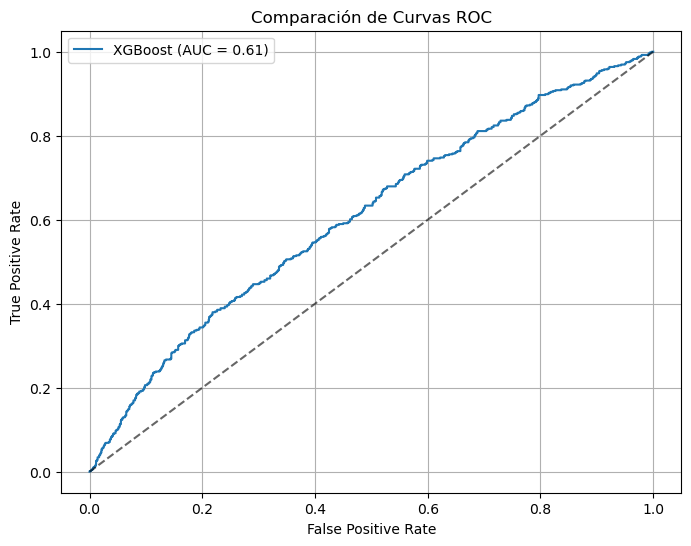

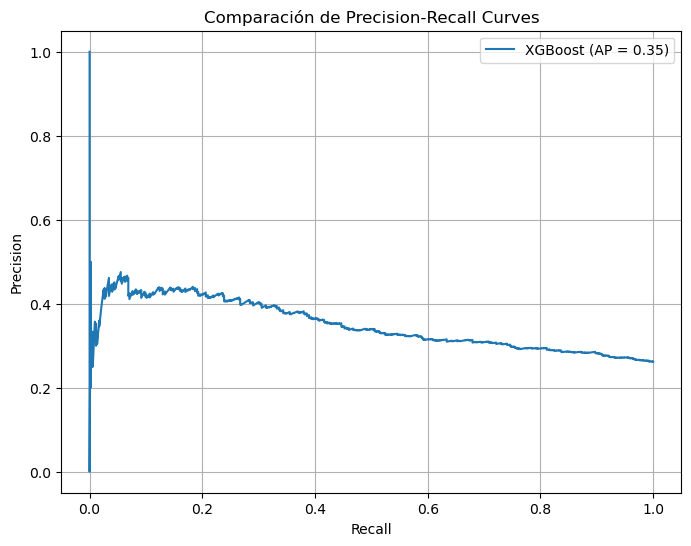

In [ ]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import GridSearchCV

# Pipeline con XGB
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__n_estimators': [500],
    'model__max_depth': [9],
    'model__learning_rate': [0.01],
    'model__subsample': [0.8],
    'model__colsample_bytree': [1.0],
    'model__scale_pos_weight': [1],
    
}

# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)
print(classification_report(y_test, y_pred_xgb))
display(evaluate_models({
    'XGBoost': best_xgb  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_xgb,'Matriz de confusión - XGBoost', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_xgb],
    labels_list=["XGBoost"],
)
plot_multiple_precision_recall_curves(y_test, {'XGBoost': y_proba_xgb})

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores parámetros encontrados:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 9, 'model__n_estimators': 500, 'model__scale_pos_weight': 1, 'model__subsample': 0.8, 'scaler__n_quantiles': 2000, 'scaler__output_distribution': 'normal'}
              precision    recall  f1-score   support

           0       0.81      0.37      0.50      1476
           1       0.30      0.76      0.43       524

    accuracy                           0.47      2000
   macro avg       0.56      0.56      0.47      2000
weighted avg       0.68      0.47      0.48      2000



,XGBoost
Score,0.469500
Accuracy,0.469500
Precision,0.298876
Recall,0.761450
F1,0.429263


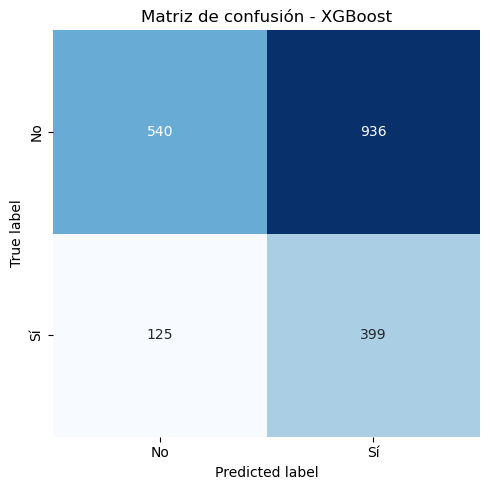

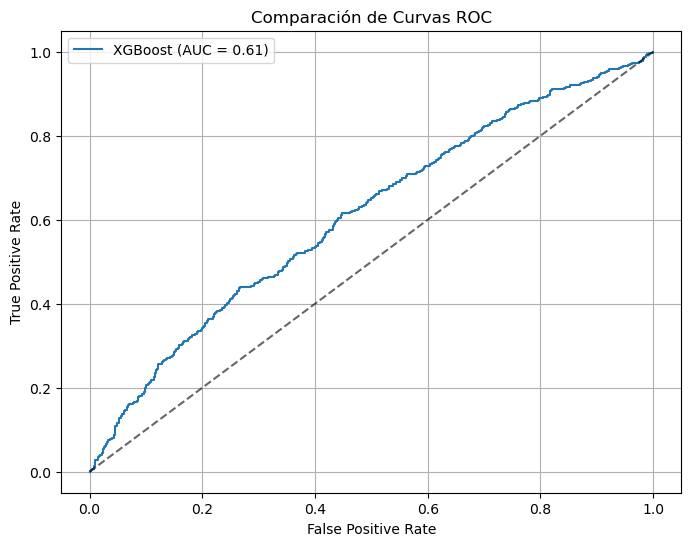

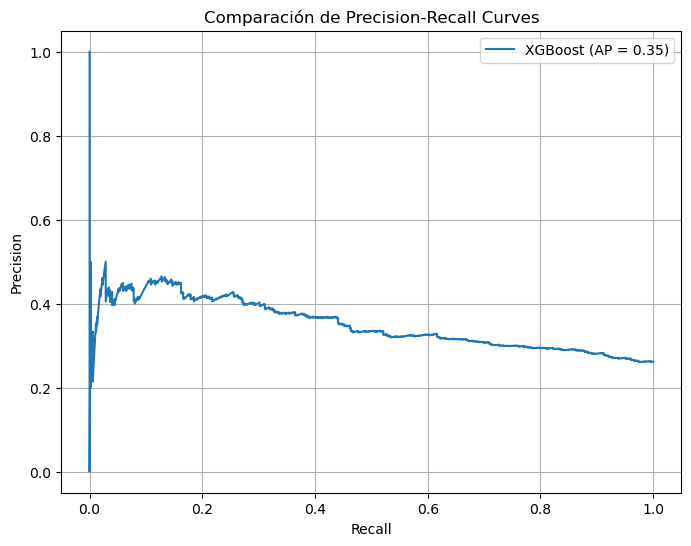

In [147]:
# ajustando qantile transformer
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000,random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__n_estimators': [500],
    'model__max_depth': [9],
    'model__learning_rate': [0.01],
    'model__subsample': [0.8],
    'model__colsample_bytree': [1.0],
    'model__scale_pos_weight': [1],
    'scaler__n_quantiles': [1000, 2000, 3000],  # Probar diferentes valores de n_quantiles
    'scaler__output_distribution': ['normal', 'uniform']  # Probar diferentes
    
}

# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)
print(classification_report(y_test, y_pred_xgb))
display(evaluate_models({
    'XGBoost': best_xgb  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_xgb,'Matriz de confusión - XGBoost', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_xgb],
    labels_list=["XGBoost"],
)
plot_multiple_precision_recall_curves(y_test, {'XGBoost': y_proba_xgb})

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejores parámetros encontrados:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 9, 'model__n_estimators': 500, 'model__scale_pos_weight': 1, 'model__subsample': 0.8, 'sampler': SMOTEENN()}
              precision    recall  f1-score   support

           0       0.82      0.37      0.51      1476
           1       0.30      0.76      0.43       524

    accuracy                           0.47      2000
   macro avg       0.56      0.57      0.47      2000
weighted avg       0.68      0.47      0.49      2000



,XGBoost
Score,0.474500
Accuracy,0.474500
Precision,0.301432
Recall,0.763359
F1,0.432199


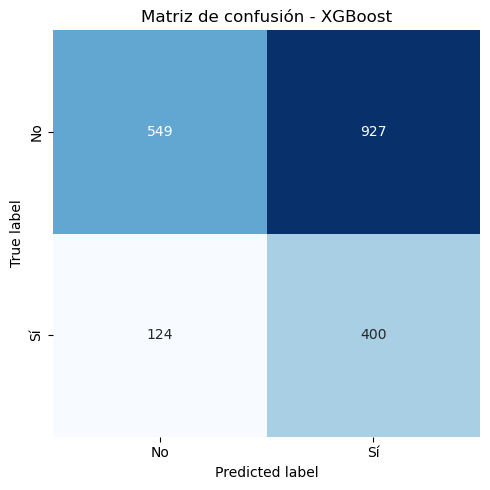

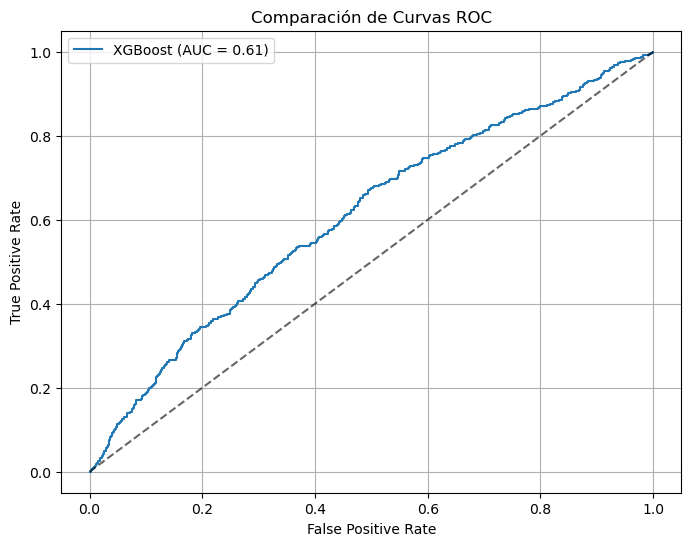

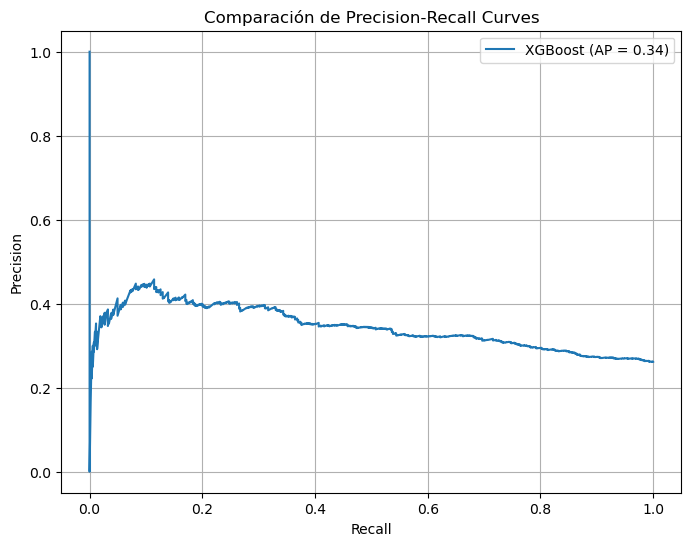

In [148]:
# ajustando los samplers
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=2000,random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__n_estimators': [500],
    'model__max_depth': [9],
    'model__learning_rate': [0.01],
    'model__subsample': [0.8],
    'model__colsample_bytree': [1.0],
    'model__scale_pos_weight': [1],
    'sampler': [
        SMOTEENN(),
        SMOTE(),
        ADASYN(),
        SMOTETomek(),
        None
    ],
    
}

# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)
print(classification_report(y_test, y_pred_xgb))
display(evaluate_models({
    'XGBoost': best_xgb  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_xgb,'Matriz de confusión - XGBoost', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_xgb],
    labels_list=["XGBoost"],
)
plot_multiple_precision_recall_curves(y_test, {'XGBoost': y_proba_xgb})

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Mejores parámetros encontrados:
{'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__scale_pos_weight': 1, 'model__subsample': 0.8}
              precision    recall  f1-score   support

           0       0.81      0.40      0.53      1476
           1       0.30      0.73      0.43       524

    accuracy                           0.48      2000
   macro avg       0.55      0.56      0.48      2000
weighted avg       0.67      0.48      0.50      2000



,XGBoost
Score,0.485000
Accuracy,0.485000
Precision,0.300787
Recall,0.729008
F1,0.425864


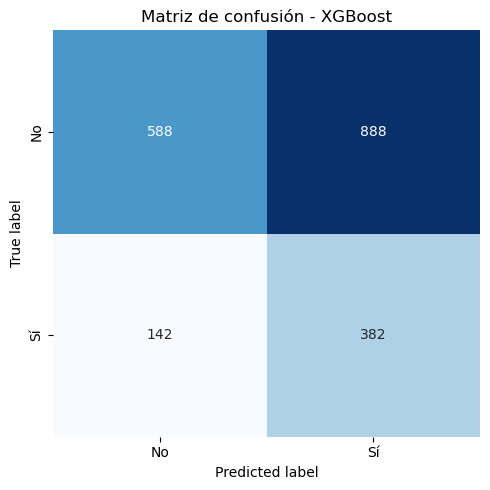

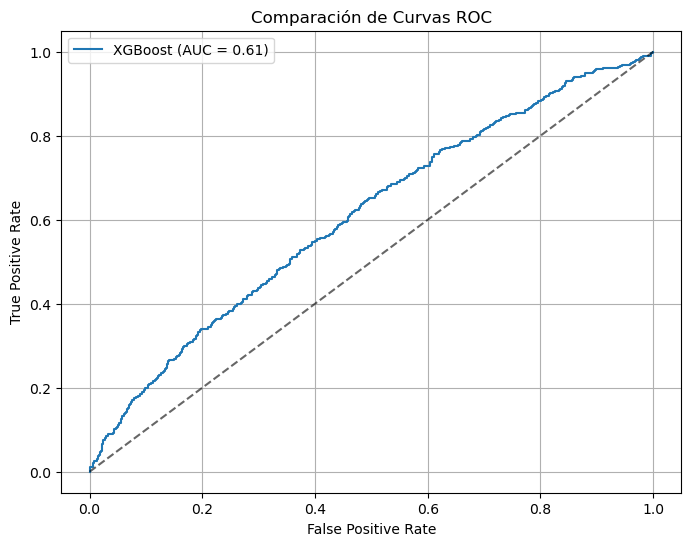

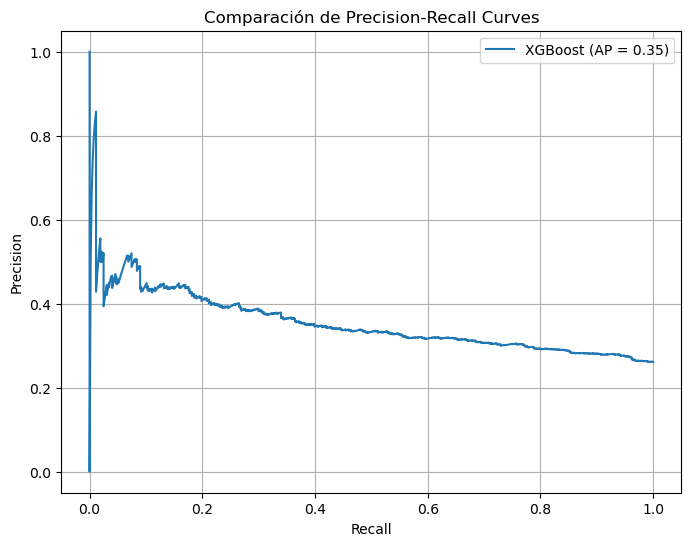

In [150]:
# ajustando parametros del modelo
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=2000,random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.6, 0.8],
    'model__colsample_bytree': [0.6, 0.8],
    'model__scale_pos_weight': [1, 2],
    'model__n_estimators': [100, 200],
    'model__gamma': [0, 0.1, 0.2],
    'model__min_child_weight': [1, 2],
}


# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)
print(classification_report(y_test, y_pred_xgb))
display(evaluate_models({
    'XGBoost': best_xgb  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_xgb,'Matriz de confusión - XGBoost', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_xgb],
    labels_list=["XGBoost"],
)
plot_multiple_precision_recall_curves(y_test, {'XGBoost': y_proba_xgb})

Fitting 5 folds for each of 2880 candidates, totalling 14400 fits
Mejores parámetros encontrados:
{'model__colsample_bytree': 0.8, 'model__gamma': 0.2, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 2, 'model__n_estimators': 100, 'model__scale_pos_weight': 1, 'model__subsample': 0.6, 'sampler': SMOTEENN(enn=EditedNearestNeighbours(),
         smote=SMOTE(k_neighbors=2, random_state=42, sampling_strategy=0.5))}
              precision    recall  f1-score   support

           0       0.80      0.44      0.57      1476
           1       0.31      0.70      0.43       524

    accuracy                           0.51      2000
   macro avg       0.56      0.57      0.50      2000
weighted avg       0.67      0.51      0.53      2000



,XGBoost
Score,0.510500
Accuracy,0.510500
Precision,0.308017
Recall,0.696565
F1,0.427150


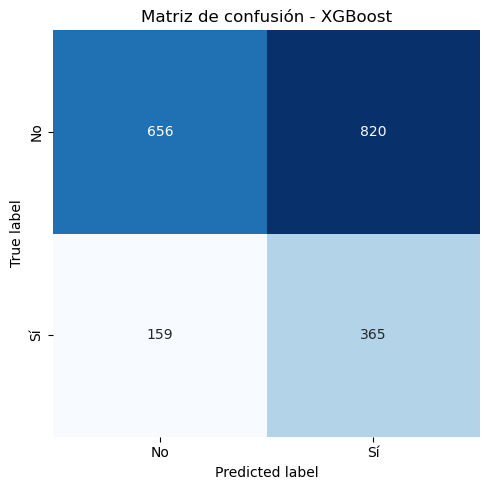

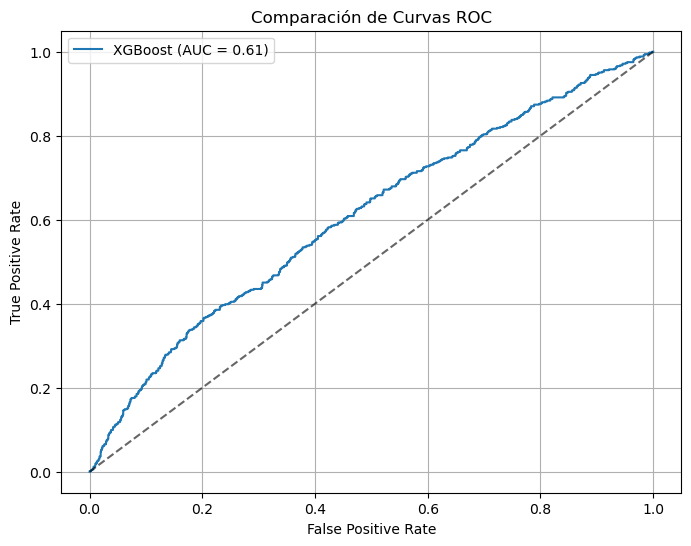

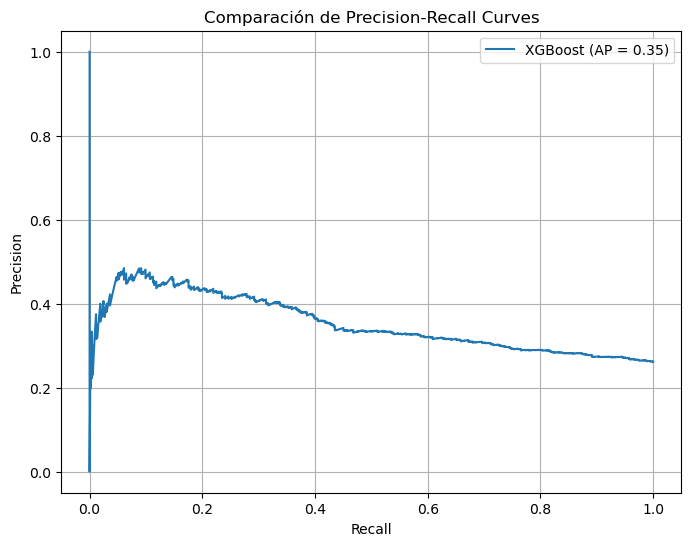

In [152]:
# ajustando parametros del modelo
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=2000,random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.6, 0.8],
    'model__colsample_bytree': [0.6, 0.8],
    'model__scale_pos_weight': [1, 2],
    'model__n_estimators': [100, 200],
    'model__gamma': [0, 0.1, 0.2],
    'model__min_child_weight': [1, 2],
    'sampler': [
        SMOTEENN(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.5, random_state=42),
            enn=EditedNearestNeighbours(n_neighbors=3)
        ),
        SMOTEENN(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.3, random_state=42),
            enn=EditedNearestNeighbours(n_neighbors=3)
        ),
        SMOTEENN(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.5, random_state=42),
            enn=EditedNearestNeighbours(n_neighbors=5)
        ),
        SMOTEENN(
            smote=SMOTE(k_neighbors=2, sampling_strategy=0.3, random_state=42),
            enn=EditedNearestNeighbours(n_neighbors=5)
        ),
        SMOTEENN()  # por default
    ]
}

# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)
print(classification_report(y_test, y_pred_xgb))
display(evaluate_models({
    'XGBoost': best_xgb  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_xgb,'Matriz de confusión - XGBoost', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_xgb],
    labels_list=["XGBoost"],
)
plot_multiple_precision_recall_curves(y_test, {'XGBoost': y_proba_xgb})

# SVM

Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ Best Params (SVM): {'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'rbf'}
✅ CV balanced_accuracy: 0.5735
              precision    recall  f1-score   support

           0       0.79      0.46      0.59      1476
           1       0.30      0.66      0.42       524

    accuracy                           0.52      2000
   macro avg       0.55      0.56      0.50      2000
weighted avg       0.67      0.52      0.54      2000



,SVM
Score,0.515500
Accuracy,0.515500
Precision,0.304310
Recall,0.660305
F1,0.416616


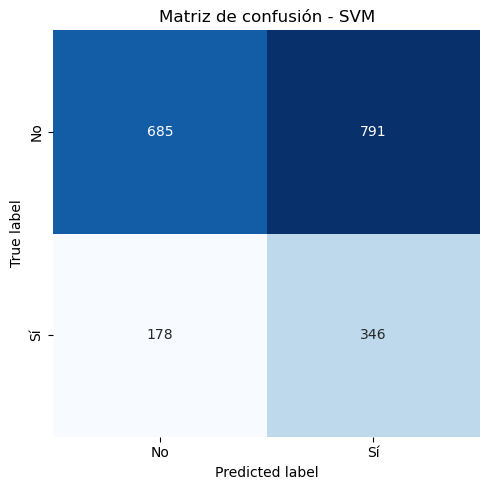

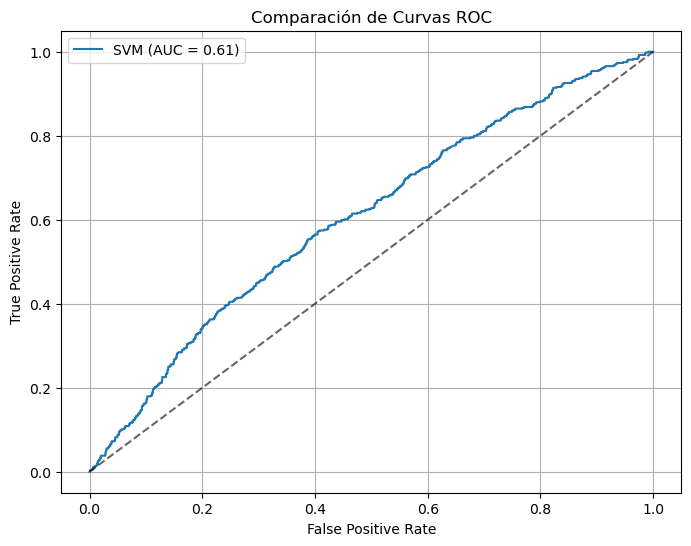

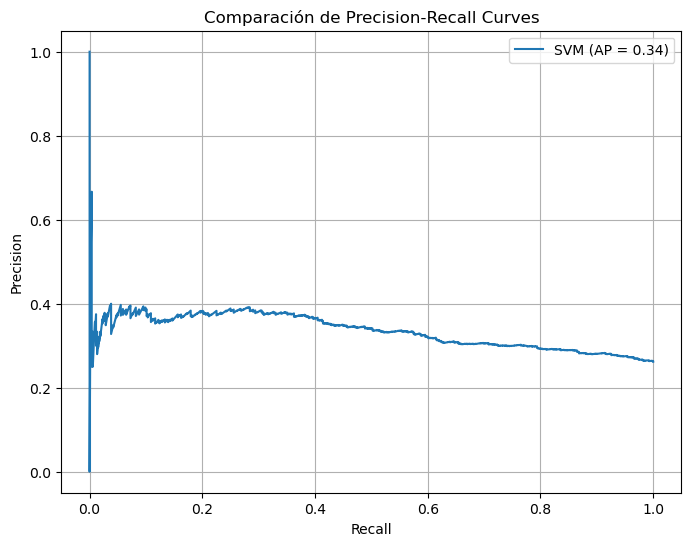

In [97]:
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from sklearn.model_selection import GridSearchCV

# Pipeline con SVM
pipe_svm = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', SVC(probability=True, random_state=42))
])

# Param grid con tus mejores parámetros fijos
param_grid_svm = {
    'model__C': [1],
    'model__kernel': ['rbf'],
    'model__class_weight': ['balanced']
}

# GridSearch
grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_

print(f"\n✅ Best Params (SVM): {grid_svm.best_params_}")
print(f"✅ CV balanced_accuracy: {grid_svm.best_score_:.4f}")

y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:,1]
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(classification_report(y_test, y_pred_svm))
display(evaluate_models({
    'SVM': best_svm  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_svm,'Matriz de confusión - SVM', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_svm],
    labels_list=["SVM"],
)
plot_multiple_precision_recall_curves(y_test, {'SVM': y_proba_svm})


Fitting 5 folds for each of 6 candidates, totalling 30 fits

✅ Best Params (SVM): {'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'rbf', 'scaler__n_quantiles': 2000, 'scaler__output_distribution': 'normal'}
✅ CV balanced_accuracy: 0.5746
              precision    recall  f1-score   support

           0       0.79      0.46      0.58      1476
           1       0.30      0.67      0.42       524

    accuracy                           0.51      2000
   macro avg       0.55      0.56      0.50      2000
weighted avg       0.67      0.51      0.54      2000



,SVM
Score,0.513000
Accuracy,0.513000
Precision,0.304007
Recall,0.666031
F1,0.417464


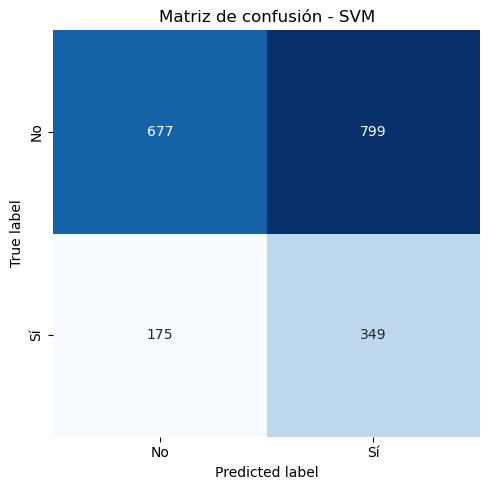

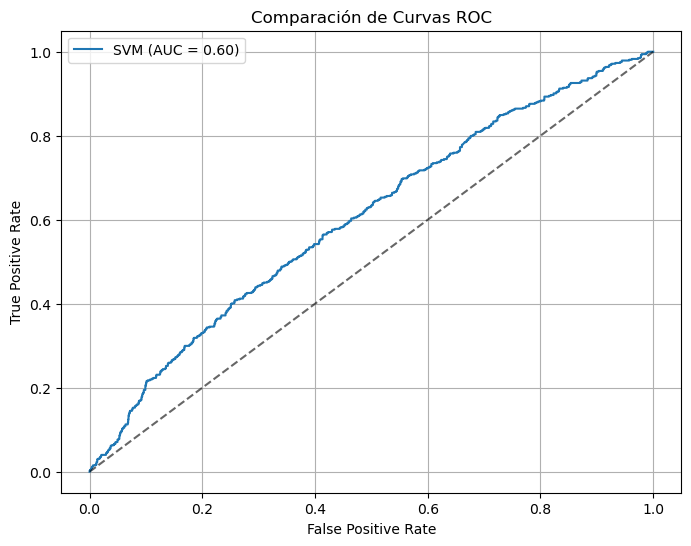

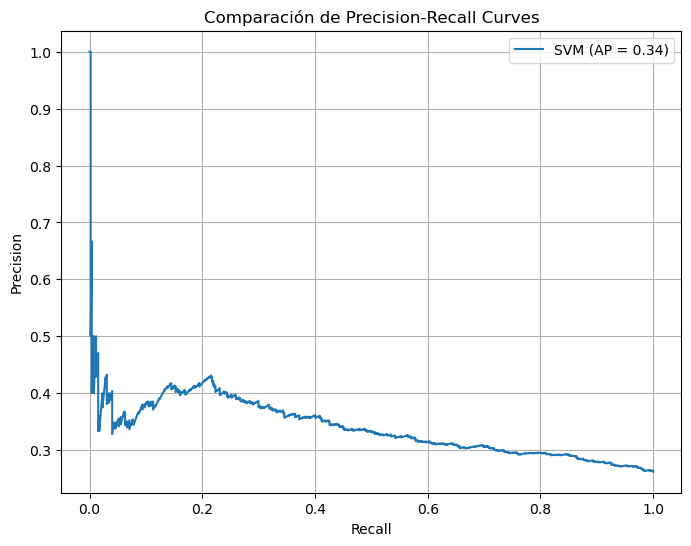

In [155]:
# ajustando Qantile Transformer
pipe_svm = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=1000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', SVC(probability=True, random_state=42))
])

# Param grid con tus mejores parámetros fijos
param_grid_svm = {
    'model__C': [1],
    'model__kernel': ['rbf'],
    'model__class_weight': ['balanced'],
    'scaler__n_quantiles': [1000, 2000, 3000],  # Probar diferentes valores de n_quantiles
    'scaler__output_distribution': ['normal', 'uniform']  # Probar diferentes
}

# GridSearch
grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_

print(f"\n✅ Best Params (SVM): {grid_svm.best_params_}")
print(f"✅ CV balanced_accuracy: {grid_svm.best_score_:.4f}")

y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:,1]
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(classification_report(y_test, y_pred_svm))
display(evaluate_models({
    'SVM': best_svm  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_svm,'Matriz de confusión - SVM', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_svm],
    labels_list=["SVM"],
)
plot_multiple_precision_recall_curves(y_test, {'SVM': y_proba_svm})


Fitting 5 folds for each of 5 candidates, totalling 25 fits

✅ Best Params (SVM): {'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'rbf', 'sampler': None}
✅ CV balanced_accuracy: 0.5847
              precision    recall  f1-score   support

           0       0.79      0.58      0.67      1476
           1       0.33      0.57      0.42       524

    accuracy                           0.58      2000
   macro avg       0.56      0.58      0.54      2000
weighted avg       0.67      0.58      0.60      2000



,SVM
Score,0.579000
Accuracy,0.579000
Precision,0.326419
Recall,0.570611
F1,0.415278


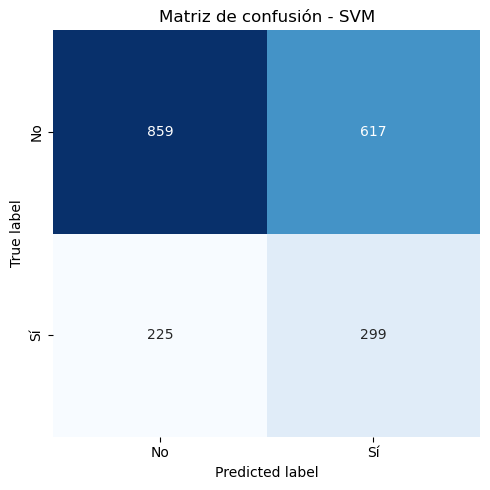

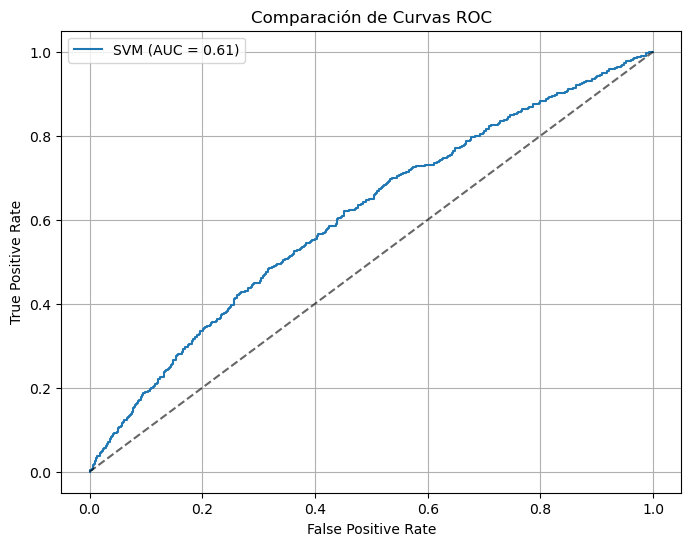

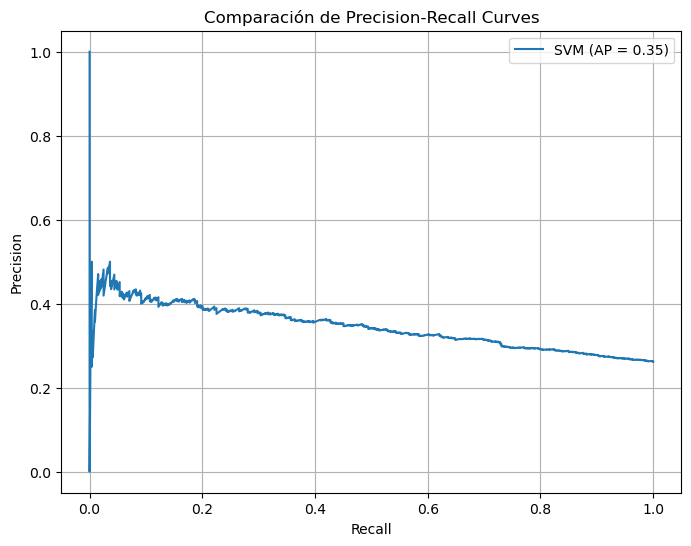

In [156]:
# ajustando samplers
pipe_svm = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal',n_quantiles=2000, random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', SVC(probability=True, random_state=42))
])

# Param grid con tus mejores parámetros fijos
param_grid_svm = {
    'model__C': [1],
    'model__kernel': ['rbf'],
    'model__class_weight': ['balanced'],
    'sampler': [
        SMOTEENN(),
        SMOTE(),
        ADASYN(),
        SMOTETomek(),
        None
    ],
  # Probar diferentes
}

# GridSearch
grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_

print(f"\n✅ Best Params (SVM): {grid_svm.best_params_}")
print(f"✅ CV balanced_accuracy: {grid_svm.best_score_:.4f}")

y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:,1]
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(classification_report(y_test, y_pred_svm))
display(evaluate_models({
    'SVM': best_svm  
}, X_test, y_test))
plot_multiple_confusion_matrix(cm_svm,'Matriz de confusión - SVM', labels=['No', 'Sí'], cmap='Blues', figsize=(5,5))
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=[y_proba_svm],
    labels_list=["SVM"],
)
plot_multiple_precision_recall_curves(y_test, {'SVM': y_proba_svm})

# Comparar Modelos

In [179]:
models_dict= {
    'Logistic': best_logit,
    'RandomForest': best_rf,
    'XGB': best_xgb,
    'SVM': best_svm,
    'Hard Voting': voting_hard,
    'Soft Voting': voting_soft
}
proba_dict = {
    'Logistic': y_proba_logit,
    'RandomForest': y_proba_rf,
    'XGB': y_proba_xgb,
    'SVM': y_proba_svm,
  
    'Soft Voting': y_proba_soft
    
}
confusion_matrix_dict = {
    'Logistic': cm_logit,
    'RandomForest': cm_rf,
    'XGB': cm_xgb,
    'SVM': cm_svm,

    'Soft Voting': cm_soft
}


In [186]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, balanced_accuracy_score, roc_auc_score
)

In [189]:
display(evaluate_models(models_dict, X_test, y_test))

,Logistic,RandomForest,XGB,SVM,Hard Voting,Soft Voting
Accuracy,0.569500,0.558500,0.510500,0.579000,0.585000,0.614000
Balanced_Accuracy,0.573551,0.585177,0.570505,0.576295,0.587129,0.582775
Precision,0.322070,0.325897,0.308017,0.326419,0.334773,0.343038
Recall,0.582061,0.641221,0.696565,0.570611,0.591603,0.517176
F1,0.414684,0.432154,0.427150,0.415278,0.427586,0.412481
ROC_AUC,0.598059,0.614704,0.606804,0.606560,NaN,0.609412


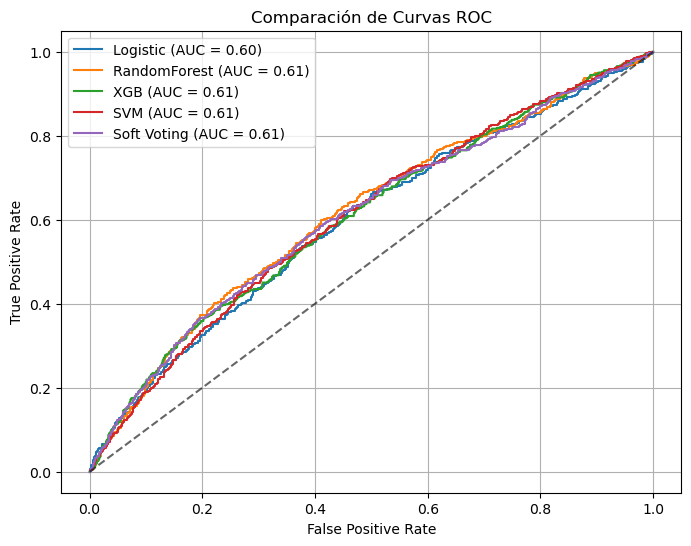

In [181]:
plot_multiple_roc_curves(
    y_true=y_test,
    y_proba_list=list(proba_dict.values()),
    labels_list=list(proba_dict.keys()),
)

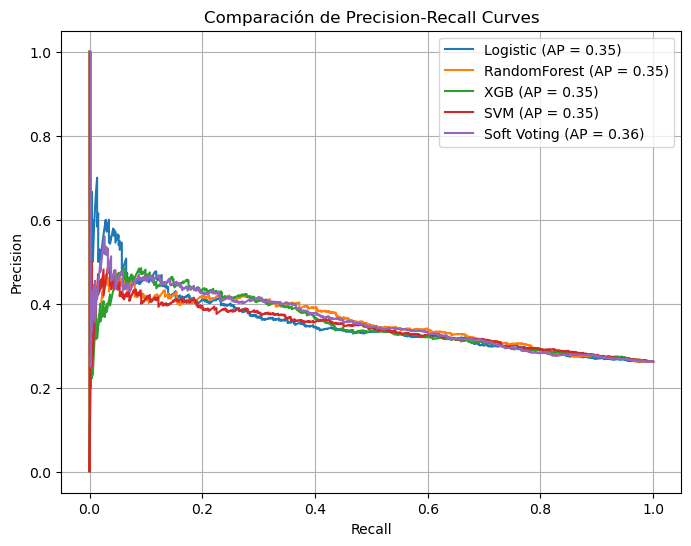

In [182]:
plot_multiple_precision_recall_curves(y_test, proba_dict, figsize=(8,6))

# Hard Voting- Modelo de ensamble

In [184]:
from sklearn.ensemble import VotingClassifier

voting_hard = VotingClassifier(
    estimators=[
        ('logit', best_logit),
        ('rf', best_rf),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    voting='hard'
)

# Entrenar
voting_hard.fit(X_train, y_train)
from sklearn.metrics import classification_report, confusion_matrix

y_pred_hard = voting_hard.predict(X_test)

print("\n📊 Classification Report (Hard Voting):")
print(classification_report(y_test, y_pred_hard))

cm_hard = confusion_matrix(y_test, y_pred_hard)
print("\nConfusion Matrix (Hard Voting):")
print(cm_hard)


📊 Classification Report (Hard Voting):
              precision    recall  f1-score   support

           0       0.80      0.58      0.67      1476
           1       0.33      0.59      0.42       524

    accuracy                           0.58      2000
   macro avg       0.57      0.58      0.55      2000
weighted avg       0.68      0.58      0.61      2000


Confusion Matrix (Hard Voting):
[[861 615]
 [217 307]]


# Soft Voting- Modelo de ensamble

In [175]:
from sklearn.ensemble import VotingClassifier

voting_soft = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('logit', best_logit),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    voting='soft',  # usa las probabilidades
    n_jobs=-1
)

# Entrenamos sobre el train
voting_soft.fit(X_train, y_train)

# Evaluamos en el test
from sklearn.metrics import classification_report, confusion_matrix

y_pred_soft = voting_soft.predict(X_test)
y_proba_soft = voting_soft.predict_proba(X_test)[:,1]
print("\n📊 Classification Report (Ensemble):")
print(classification_report(y_test, y_pred_soft))

cm_soft = confusion_matrix(y_test, y_pred_soft)
print("\nConfusion Matrix (Ensemble):")
print(cm_soft)



📊 Classification Report (Ensemble):
              precision    recall  f1-score   support

           0       0.79      0.65      0.71      1476
           1       0.34      0.52      0.41       524

    accuracy                           0.61      2000
   macro avg       0.57      0.58      0.56      2000
weighted avg       0.67      0.61      0.63      2000


Confusion Matrix (Ensemble):
[[957 519]
 [253 271]]


# Ajustando Threshold

In [168]:
y_proba_ens = ensemble.predict_proba(X_test)[:,1]  # promedio de probas del ensemble

for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred_thresh = (y_proba_ens >= t).astype(int)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    cm = confusion_matrix(y_test, y_pred_thresh)
    fp = cm[0][1]
    tp = cm[1][1]
    print(f"\n=== Threshold: {t:.2f} ===")
    print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
    print(f"Confusion Matrix:\n{cm}")
    print(f"FP: {fp}, TP: {tp}")



=== Threshold: 0.30 ===
Precision: 0.276 | Recall: 0.903 | F1: 0.423
Confusion Matrix:
[[ 234 1242]
 [  51  473]]
FP: 1242, TP: 473

=== Threshold: 0.40 ===
Precision: 0.306 | Recall: 0.718 | F1: 0.429
Confusion Matrix:
[[623 853]
 [148 376]]
FP: 853, TP: 376

=== Threshold: 0.50 ===
Precision: 0.343 | Recall: 0.521 | F1: 0.414
Confusion Matrix:
[[953 523]
 [251 273]]
FP: 523, TP: 273

=== Threshold: 0.60 ===
Precision: 0.401 | Recall: 0.267 | F1: 0.321
Confusion Matrix:
[[1267  209]
 [ 384  140]]
FP: 209, TP: 140


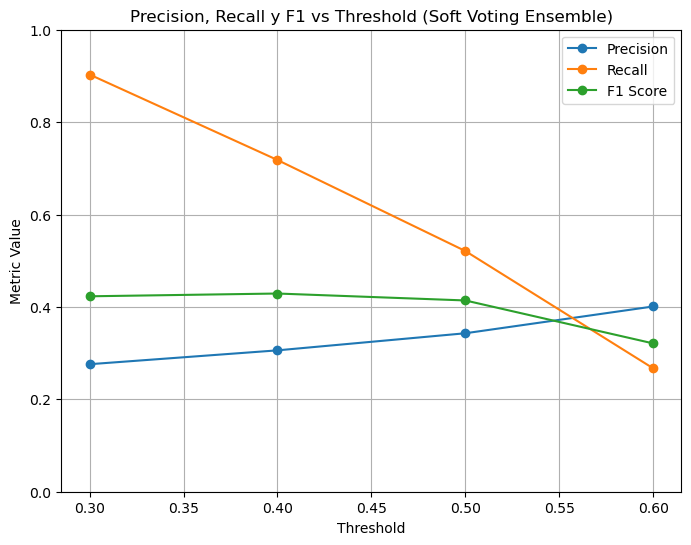

In [169]:
import matplotlib.pyplot as plt

# Valores obtenidos de tu loop
thresholds = [0.3, 0.4, 0.5, 0.6]
precisions = [0.276, 0.306, 0.343, 0.401]
recalls    = [0.903, 0.718, 0.521, 0.267]
f1_scores  = [0.423, 0.429, 0.414, 0.321]

plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, f1_scores, marker='o', label='F1 Score')

plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.title('Precision, Recall y F1 vs Threshold (Soft Voting Ensemble)')
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()


In [170]:
from sklearn.metrics import classification_report, confusion_matrix

# Ajustar el threshold a 0.4
optimal_threshold = 0.4
y_pred_final = (y_proba_ens >= optimal_threshold).astype(int)

# Classification report
print("\n📊 Classification Report (Soft Voting Ensemble - Threshold 0.4):")
print(classification_report(y_test, y_pred_final))

# Confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)
print("\nConfusion Matrix (Soft Voting Ensemble - Threshold 0.4):")
print(cm_final)



📊 Classification Report (Soft Voting Ensemble - Threshold 0.4):
              precision    recall  f1-score   support

           0       0.81      0.42      0.55      1476
           1       0.31      0.72      0.43       524

    accuracy                           0.50      2000
   macro avg       0.56      0.57      0.49      2000
weighted avg       0.68      0.50      0.52      2000


Confusion Matrix (Soft Voting Ensemble - Threshold 0.4):
[[623 853]
 [148 376]]


# Probando con los diferentes dataset para comparar

In [193]:
# Primero split solo para obtener índices consistentes
idx_train, idx_test = train_test_split(
    y.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Ahora creás tus X_train y X_test para cada dataset con esos índices
x_train = x.loc[idx_train]
x_test  = x.loc[idx_test]

x_abs_train = x_abs.loc[idx_train]
x_abs_test  = x_abs.loc[idx_test]

x_abs_filtered_train = x_abs_filtered.loc[idx_train]
x_abs_filtered_test  = x_abs_filtered.loc[idx_test]

x_rel_train = x_rel.loc[idx_train]
x_rel_test  = x_rel.loc[idx_test]

x_rel_filtered_train = x_rel_filtered.loc[idx_train]
x_rel_filtered_test  = x_rel_filtered.loc[idx_test]

y_train = y.loc[idx_train]
y_test  = y.loc[idx_test]



In [194]:
from sklearn.base import clone

# ==============================
# Dataset completo
# ==============================
best_logit_x = clone(best_logit).fit(x_train, y_train)
best_rf_x    = clone(best_rf).fit(x_train, y_train)
best_xgb_x   = clone(best_xgb).fit(x_train, y_train)
best_svm_x   = clone(best_svm).fit(x_train, y_train)
voting_soft_x = clone(voting_soft).fit(x_train, y_train)
voting_hard_x = clone(voting_hard).fit(x_train, y_train)

# ==============================
# Solo absolutas
# ==============================
best_logit_x_abs = clone(best_logit).fit(x_abs_train, y_train)
best_rf_x_abs    = clone(best_rf).fit(x_abs_train, y_train)
best_xgb_x_abs   = clone(best_xgb).fit(x_abs_train, y_train)
best_svm_x_abs   = clone(best_svm).fit(x_abs_train, y_train)
voting_soft_x_abs = clone(voting_soft).fit(x_abs_train, y_train)
voting_hard_x_abs = clone(voting_hard).fit(x_abs_train, y_train)

# ==============================
# Absolutas filtradas
# ==============================
best_logit_x_abs_f = clone(best_logit).fit(x_abs_filtered_train, y_train)
best_rf_x_abs_f    = clone(best_rf).fit(x_abs_filtered_train, y_train)
best_xgb_x_abs_f   = clone(best_xgb).fit(x_abs_filtered_train, y_train)
best_svm_x_abs_f   = clone(best_svm).fit(x_abs_filtered_train, y_train)
voting_soft_x_abs_f = clone(voting_soft).fit(x_abs_filtered_train, y_train)
voting_hard_x_abs_f = clone(voting_hard).fit(x_abs_filtered_train, y_train)

# ==============================
# Solo relativas
# ==============================
best_logit_x_rel = clone(best_logit).fit(x_rel_train, y_train)
best_rf_x_rel    = clone(best_rf).fit(x_rel_train, y_train)
best_xgb_x_rel   = clone(best_xgb).fit(x_rel_train, y_train)
best_svm_x_rel   = clone(best_svm).fit(x_rel_train, y_train)
voting_soft_x_rel = clone(voting_soft).fit(x_rel_train, y_train)
voting_hard_x_rel = clone(voting_hard).fit(x_rel_train, y_train)

# ==============================
# Relativas filtradas
# ==============================
best_logit_x_rel_f = clone(best_logit).fit(x_rel_filtered_train, y_train)
best_rf_x_rel_f    = clone(best_rf).fit(x_rel_filtered_train, y_train)
best_xgb_x_rel_f   = clone(best_xgb).fit(x_rel_filtered_train, y_train)
best_svm_x_rel_f   = clone(best_svm).fit(x_rel_filtered_train, y_train)
voting_soft_x_rel_f = clone(voting_soft).fit(x_rel_filtered_train, y_train)
voting_hard_x_rel_f = clone(voting_hard).fit(x_rel_filtered_train, y_train)


In [195]:
# ==============================
# EVALUACIÓN DATASET COMPLETO (x)
# ==============================
df_results_x = evaluate_models({
    'Logistic': best_logit_x,
    'RF': best_rf_x,
    'XGB': best_xgb_x,
    'SVM': best_svm_x,
    'Soft Voting': voting_soft_x,
    'Hard Voting': voting_hard_x
}, x_test, y_test)

# ==============================
# EVALUACIÓN SOLO ABSOLUTAS (x_abs)
# ==============================
df_results_x_abs = evaluate_models({
    'Logistic': best_logit_x_abs,
    'RF': best_rf_x_abs,
    'XGB': best_xgb_x_abs,
    'SVM': best_svm_x_abs,
    'Soft Voting': voting_soft_x_abs,
    'Hard Voting': voting_hard_x_abs
}, x_abs_test, y_test)

# ==============================
# EVALUACIÓN ABS FILTRADAS (x_abs_filtered)
# ==============================
df_results_x_abs_f = evaluate_models({
    'Logistic': best_logit_x_abs_f,
    'RF': best_rf_x_abs_f,
    'XGB': best_xgb_x_abs_f,
    'SVM': best_svm_x_abs_f,
    'Soft Voting': voting_soft_x_abs_f,
    'Hard Voting': voting_hard_x_abs_f
}, x_abs_filtered_test, y_test)

# ==============================
# EVALUACIÓN SOLO RELATIVAS (x_rel)
# ==============================
df_results_x_rel = evaluate_models({
    'Logistic': best_logit_x_rel,
    'RF': best_rf_x_rel,
    'XGB': best_xgb_x_rel,
    'SVM': best_svm_x_rel,
    'Soft Voting': voting_soft_x_rel,
    'Hard Voting': voting_hard_x_rel
}, x_rel_test, y_test)

# ==============================
# EVALUACIÓN REL FILTRADAS (x_rel_filtered)
# ==============================
df_results_x_rel_f = evaluate_models({
    'Logistic': best_logit_x_rel_f,
    'RF': best_rf_x_rel_f,
    'XGB': best_xgb_x_rel_f,
    'SVM': best_svm_x_rel_f,
    'Soft Voting': voting_soft_x_rel_f,
    'Hard Voting': voting_hard_x_rel_f
}, x_rel_filtered_test, y_test)

# ==============================
# MOSTRAR RESULTADOS
# ==============================
print("\n📊 Resultados - Dataset Completo (x)")
display(df_results_x.T)

print("\n📊 Resultados - Absolutas (x_abs)")
display(df_results_x_abs.T)

print("\n📊 Resultados - Absolutas Filtradas (x_abs_filtered)")
display(df_results_x_abs_f.T)

print("\n📊 Resultados - Relativas (x_rel)")
display(df_results_x_rel.T)

print("\n📊 Resultados - Relativas Filtradas (x_rel_filtered)")
display(df_results_x_rel_f.T)



📊 Resultados - Dataset Completo (x)


,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
Logistic,0.5840,0.573528,0.326185,0.551527,0.409929,0.598383
RF,0.5565,0.581976,0.323615,0.635496,0.428847,0.612522
XGB,0.5210,0.572079,0.310646,0.679389,0.426347,0.614931
SVM,0.6105,0.584712,0.342787,0.530534,0.416479,0.599009
Soft Voting,0.6295,0.587737,0.353576,0.500000,0.414229,0.610589
Hard Voting,0.5930,0.583318,0.335227,0.562977,0.420228,NaN



📊 Resultados - Absolutas (x_abs)


,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
Logistic,0.5770,0.565092,0.318694,0.540076,0.400850,0.601086
RF,0.5555,0.580067,0.322298,0.631679,0.426821,0.607720
XGB,0.5210,0.571464,0.310315,0.677481,0.425659,0.601467
SVM,0.6005,0.575475,0.332928,0.522901,0.406830,0.593805
Soft Voting,0.6315,0.570629,0.342688,0.442748,0.386345,0.608794
Hard Voting,0.5945,0.579411,0.333333,0.547710,0.414440,NaN



📊 Resultados - Absolutas Filtradas (x_abs_filtered)


,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
Logistic,0.5815,0.568141,0.321957,0.540076,0.403421,0.604908
RF,0.5470,0.581078,0.320826,0.652672,0.430189,0.612201
XGB,0.5065,0.566564,0.305299,0.692748,0.423818,0.608605
SVM,0.6160,0.590900,0.349010,0.538168,0.423423,0.604220
Soft Voting,0.6370,0.594049,0.361644,0.503817,0.421053,0.612135
Hard Voting,0.5995,0.583413,0.337632,0.549618,0.418301,NaN



📊 Resultados - Relativas (x_rel)


,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
Logistic,0.5755,0.563461,0.317210,0.538168,0.399151,0.596625
RF,0.5645,0.591088,0.330732,0.646947,0.437702,0.609225
XGB,0.5135,0.560844,0.303243,0.660305,0.415616,0.596090
SVM,0.5915,0.565685,0.323281,0.511450,0.396157,0.595297
Soft Voting,0.6310,0.583214,0.351389,0.482824,0.406752,0.607632
Hard Voting,0.5870,0.576176,0.328798,0.553435,0.412518,NaN



📊 Resultados - Relativas Filtradas (x_rel_filtered)


,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
Logistic,0.5730,0.574076,0.323340,0.576336,0.414266,0.596948
RF,0.5585,0.585177,0.325897,0.641221,0.432154,0.614704
XGB,0.5105,0.570505,0.308017,0.696565,0.427150,0.606804
SVM,0.5790,0.576295,0.326419,0.570611,0.415278,0.606560
Soft Voting,0.6145,0.581883,0.342675,0.513359,0.411001,0.609647
Hard Voting,0.5855,0.586853,0.334778,0.589695,0.427091,NaN


# Satcking Classifier- Modelo de ensamable

In [164]:
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Stacking con probabilities y XGBoost como meta-modelo
stacking = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('logit', best_logit),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    final_estimator=XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# Entrenamos el stacking
stacking.fit(X_train, y_train)

# Evaluación en test
y_pred_stack = stacking.predict(X_test)

print("\n📊 Classification Report (Stacking - proba + XGB):")
print(classification_report(y_test, y_pred_stack))

cm_stack = confusion_matrix(y_test, y_pred_stack)
print("\nConfusion Matrix (Stacking - proba + XGB):")
print(cm_stack)



📊 Classification Report (Stacking - proba + XGB):
              precision    recall  f1-score   support

           0       0.75      0.92      0.82      1476
           1       0.34      0.12      0.18       524

    accuracy                           0.71      2000
   macro avg       0.54      0.52      0.50      2000
weighted avg       0.64      0.71      0.65      2000


Confusion Matrix (Stacking - proba + XGB):
[[1351  125]
 [ 461   63]]


In [167]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

import pandas as pd

# ================================
# PROBABILIDADES DEL STACKING
# ================================
y_proba_stack = stacking.predict_proba(X_test)[:,1]

# Umbrales a probar
thresholds = [0.1,0.2,0.3, 0.4, 0.5, 0.6,0.7, 0.8, 0.9]

# Guardar resultados
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_stack >= threshold).astype(int)
    
    # Calcular métricas
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    cm = confusion_matrix(y_test, y_pred_thresh)
    
    # Mostrar resultados en consola
    print(f"\n=== Threshold: {threshold} ===")
    print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
    print("Confusion Matrix:")
    print(cm)
    
    # Guardar en lista
    threshold_results.append({
        'Threshold': threshold,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'TN': cm[0,0],
        'FP': cm[0,1],
        'FN': cm[1,0],
        'TP': cm[1,1]
    })

# Convertir a DataFrame para analizar mejor
df_thresholds = pd.DataFrame(threshold_results)
print("\n📊 Summary of thresholds:")
print(df_thresholds)



=== Threshold: 0.1 ===
Precision: 0.271 | Recall: 0.861 | F1: 0.413
Confusion Matrix:
[[ 265 1211]
 [  73  451]]

=== Threshold: 0.2 ===
Precision: 0.293 | Recall: 0.630 | F1: 0.400
Confusion Matrix:
[[679 797]
 [194 330]]

=== Threshold: 0.3 ===
Precision: 0.313 | Recall: 0.401 | F1: 0.352
Confusion Matrix:
[[1016  460]
 [ 314  210]]

=== Threshold: 0.4 ===
Precision: 0.308 | Recall: 0.206 | F1: 0.247
Confusion Matrix:
[[1233  243]
 [ 416  108]]

=== Threshold: 0.5 ===
Precision: 0.335 | Recall: 0.120 | F1: 0.177
Confusion Matrix:
[[1351  125]
 [ 461   63]]

=== Threshold: 0.6 ===
Precision: 0.327 | Recall: 0.063 | F1: 0.106
Confusion Matrix:
[[1408   68]
 [ 491   33]]

=== Threshold: 0.7 ===
Precision: 0.256 | Recall: 0.021 | F1: 0.039
Confusion Matrix:
[[1444   32]
 [ 513   11]]

=== Threshold: 0.8 ===
Precision: 0.118 | Recall: 0.004 | F1: 0.007
Confusion Matrix:
[[1461   15]
 [ 522    2]]

=== Threshold: 0.9 ===
Precision: 0.000 | Recall: 0.000 | F1: 0.000
Confusion Matrix:
[[147

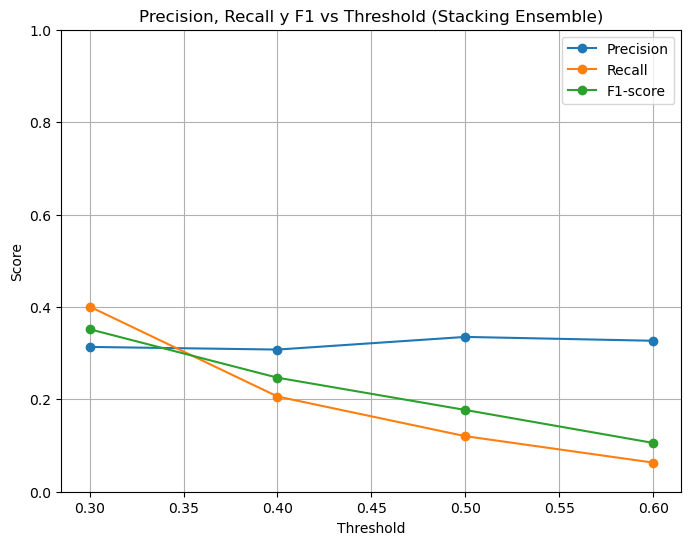

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(df_thresholds['Threshold'], df_thresholds['Precision'], marker='o', label='Precision')
plt.plot(df_thresholds['Threshold'], df_thresholds['Recall'], marker='o', label='Recall')
plt.plot(df_thresholds['Threshold'], df_thresholds['F1'], marker='o', label='F1-score')

plt.title("Precision, Recall y F1 vs Threshold (Stacking Ensemble)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()


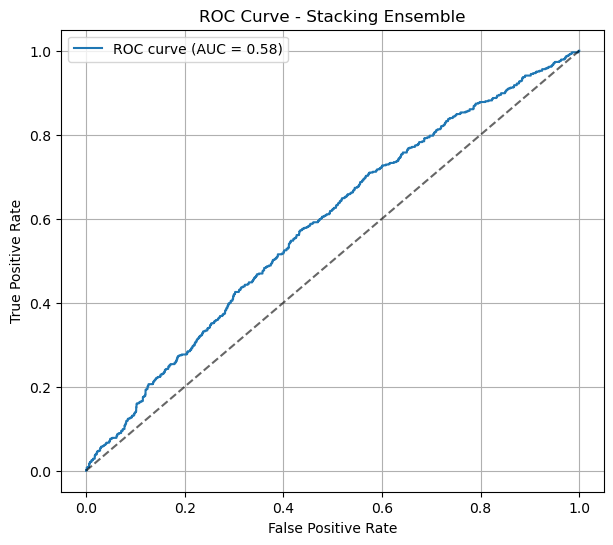

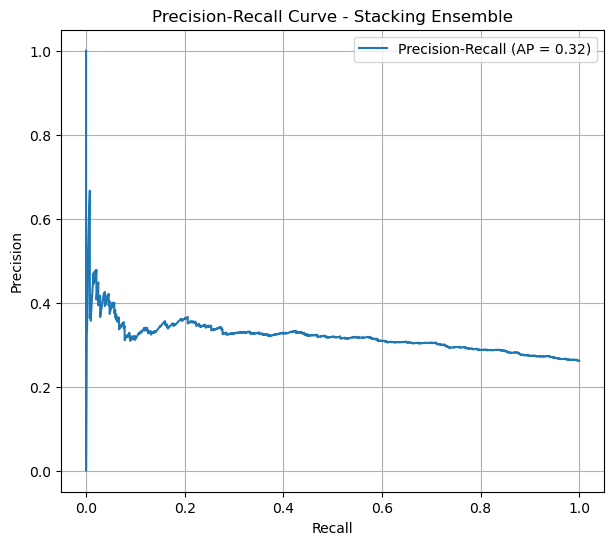

In [67]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# ============================
# ROC Curve
# ============================
auc = roc_auc_score(y_test, y_proba_stack)
fpr, tpr, _ = roc_curve(y_test, y_proba_stack)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Ensemble')
plt.legend()
plt.grid(True)
plt.show()

# ============================
# Precision-Recall Curve
# ============================
prec, rec, _ = precision_recall_curve(y_test, y_proba_stack)
avg_prec = average_precision_score(y_test, y_proba_stack)

plt.figure(figsize=(7,6))
plt.plot(rec, prec, label=f'Precision-Recall (AP = {avg_prec:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Stacking Ensemble')
plt.legend()
plt.grid(True)
plt.show()



Fitting 5 folds for each of 1 candidates, totalling 5 fits


Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ Best Params (SVM): {'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'rbf'}
✅ CV balanced_accuracy: 0.5742


Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ CV balanced_accuracy mean: 0.5767

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.50      0.64      7381
           1       0.36      0.81      0.50      2619

    accuracy                           0.58     10000
   macro avg       0.62      0.65      0.57     10000
weighted avg       0.75      0.58      0.60     10000


Confusion Matrix:
[[3664 3717]
 [ 490 2129]]


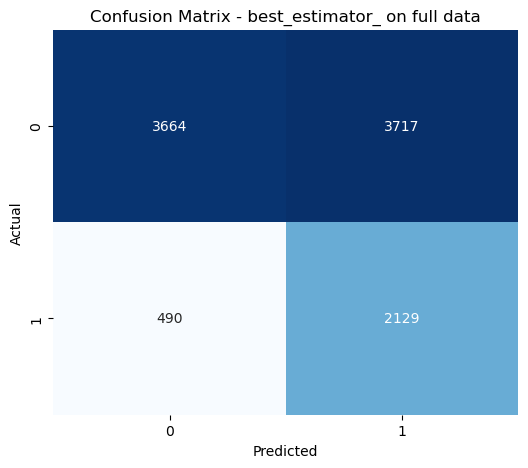

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN

# ==============================
# SELECCIONA TU DATASET
# ==============================
X_dataset = x_abs_filtered  # o x, x_abs, x_rel, x_rel_filtered
y_dataset = y

# ==============================
# PIPELINE CON RANDOM FOREST
# ==============================
pipe_random_forest = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        max_depth=10,
        min_samples_leaf=3,
        min_samples_split=5,
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# ==============================
# GRIDSEARCH SOBRE TODA LA DATA
# ==============================
param_grid = {}
grid = GridSearchCV(
    estimator=pipe_random_forest,
    param_grid=param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)
grid.fit(X_dataset, y_dataset)

print(f"\n✅ CV balanced_accuracy mean: {grid.best_score_:.4f}")

# ==============================
# MATRIZ DE CONFUSIÓN USANDO TODA LA DATA
# ==============================
y_pred = grid.best_estimator_.predict(X_dataset)

print("\n📊 Classification Report:")
print(classification_report(y_dataset, y_pred))

cm_rf = confusion_matrix(y_dataset, y_pred)
print("\nConfusion Matrix:")
print(cm_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - best_estimator_ on full data")
plt.show()



📊 Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.88      0.50      0.64      7381
           1       0.36      0.81      0.50      2619

    accuracy                           0.58     10000
   macro avg       0.62      0.65      0.57     10000
weighted avg       0.75      0.58      0.60     10000


Confusion Matrix:
[[3664 3717]
 [ 490 2129]]


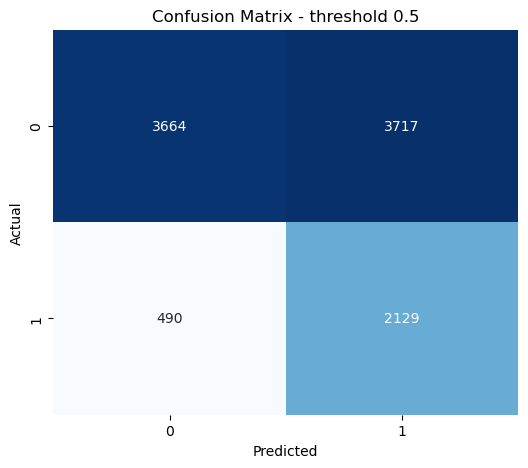


🔥 ROC-AUC: 0.7239


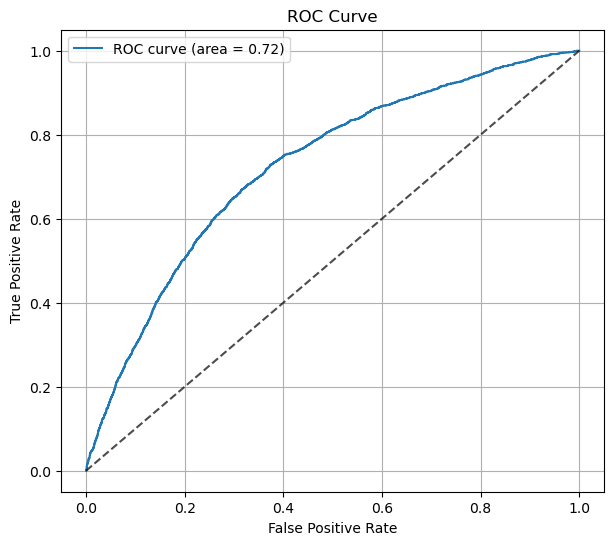

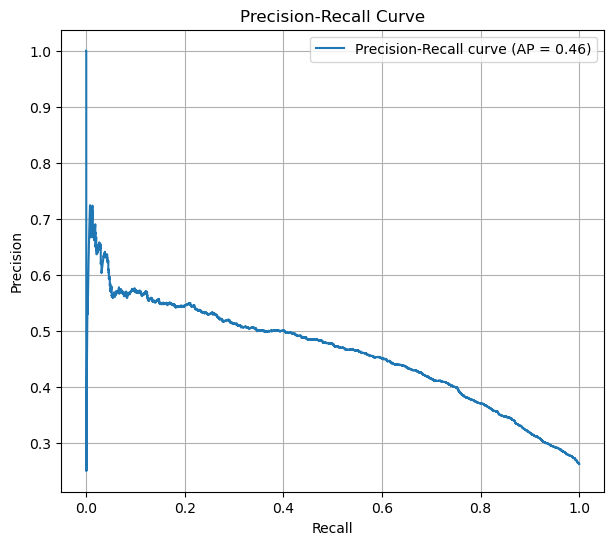

In [51]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ===========================
# PREDICCIONES PROBABILISTICAS
# ===========================
y_proba = grid.best_estimator_.predict_proba(X_dataset)[:,1]

# Puedes cambiar esto
threshold = 0.5
y_pred_thresh = (y_proba >= threshold).astype(int)

# ===========================
# NUEVO REPORT
# ===========================
print(f"\n📊 Classification Report (threshold={threshold}):")
print(classification_report(y_dataset, y_pred_thresh))

cm_rf = confusion_matrix(y_dataset, y_pred_thresh)
print("\nConfusion Matrix:")
print(cm_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - threshold {threshold}")
plt.show()

# ===========================
# ROC AUC Y CURVA
# ===========================
auc = roc_auc_score(y_dataset, y_proba)
print(f"\n🔥 ROC-AUC: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_dataset, y_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC curve (area = {auc:.2f})")
plt.plot([0,1], [0,1], 'k--', alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# ===========================
# PRECISION-RECALL CURVE
# ===========================
prec, rec, _ = precision_recall_curve(y_dataset, y_proba)
avg_prec = average_precision_score(y_dataset, y_proba)

plt.figure(figsize=(7,6))
plt.plot(rec, prec, label=f"Precision-Recall curve (AP = {avg_prec:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

{}


Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ CV balanced_accuracy mean: 0.5840

📊 Classification Report con threshold ajustado:
              precision    recall  f1-score   support

           0       0.80      0.57      0.66      1476
           1       0.33      0.60      0.42       524

    accuracy                           0.57      2000
   macro avg       0.56      0.58      0.54      2000
weighted avg       0.67      0.57      0.60      2000


Confusion Matrix:
[[837 639]
 [212 312]]


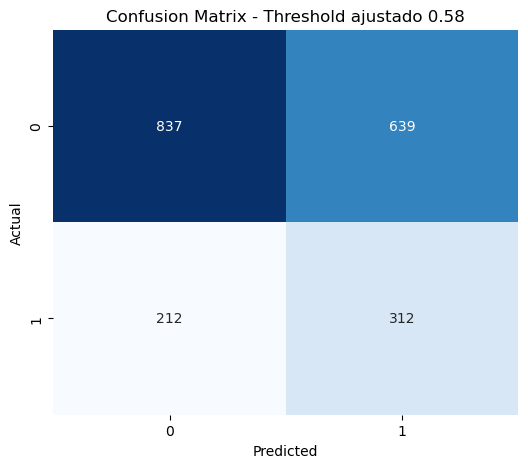

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN

# ==============================
# PIPELINE CON PARAMS FIJOS
# ==============================
pipe_random_forest = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        max_depth=10,
        min_samples_leaf=3,
        min_samples_split=5,
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# ==============================
# GRIDSEARCH CON CROSS-VAL Y SCORING BALANCED ACCURACY
# ==============================
param_grid = {}  # no cambias nada, solo valida
grid = GridSearchCV(
    estimator=pipe_random_forest,
    param_grid=param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)
grid.fit(x_rel_filtered,y_rel_train)

print(f"\n✅ CV balanced_accuracy mean: {grid.best_score_:.4f}")

# ==============================
# EVALUACIÓN EN TEST
# ==============================
y_proba = grid.predict_proba(X_p_f_test)[:,1]
threshold = 0.58
y_pred_thresh = (y_proba >= threshold).astype(int)

print("\n📊 Classification Report con threshold ajustado:")
print(classification_report(y_p_f_test, y_pred_thresh))

cm_rf   = confusion_matrix(y_p_f_test, y_pred_thresh)
print("\nConfusion Matrix:")
print(cm_rf )

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf , annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Threshold ajustado 0.58")
plt.show()


Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ CV balanced_accuracy mean: 0.5724

📊 Classification Report con threshold ajustado:
              precision    recall  f1-score   support

           0       0.78      0.58      0.67      1476
           1       0.32      0.55      0.40       524

    accuracy                           0.57      2000
   macro avg       0.55      0.56      0.54      2000
weighted avg       0.66      0.57      0.60      2000


Confusion Matrix:
[[861 615]
 [238 286]]


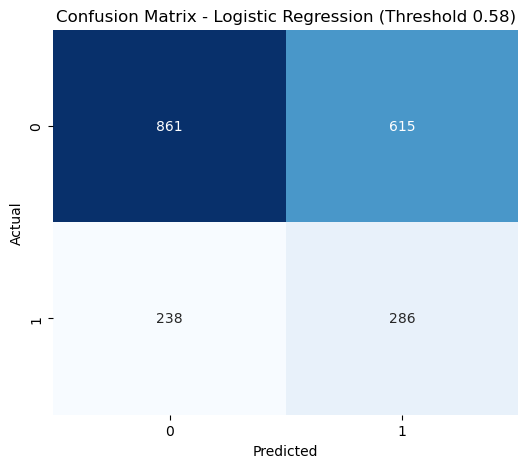

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# PIPELINE CON LOGISTIC REGRESSION
# =========================================
pipe_logistic = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(
        C=0.1,
        penalty='l1',
        solver='saga',
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

# =========================================
# GRIDSEARCH PARA VALIDAR balanced_accuracy CON CV=5
# =========================================
param_grid = {}  # no cambia nada, solo valida config fija
grid = GridSearchCV(
    estimator=pipe_logistic,
    param_grid=param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)
grid.fit(x_rel, y_absy_train)

print(f"\n✅ CV balanced_accuracy mean: {grid.best_score_:.4f}")

# =========================================
# EVALUACIÓN EN TEST
# =========================================
y_proba = grid.predict_proba(X_abs_test)[:,1]
threshold = 0.55
y_pred_thresh = (y_proba >= threshold).astype(int)

print("\n📊 Classification Report con threshold ajustado:")
print(classification_report(y_abs_test, y_pred_thresh))

cm_lr = confusion_matrix(y_abs_test, y_pred_thresh)
print("\nConfusion Matrix:")
print(cm_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Threshold 0.58)")
plt.show()


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# ==============================
# PIPELINE CON XGBOOST
# ==============================
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        scale_pos_weight=1,  # ajusta según tu dataset si quieres
        max_depth=5,
        learning_rate=0.1,
        n_estimators=100,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# ==============================
# VALIDACIÓN CON CROSS-VAL
# ==============================
param_grid = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [3, 5, 7, 9],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__scale_pos_weight': [1, 2, 3]  # para desbalance
}  # solo valida esa configuración
grid = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)
grid.fit(X_abs_train, y_abs_train)

print(f"\n✅ CV balanced_accuracy mean: {grid.best_score_:.4f}")

# ==============================
# EVALUACIÓN EN TEST CON THRESHOLD
# ==============================
y_proba = grid.predict_proba(X_abs_test)[:,1]

thresholds = np.linspace(0, 1, 101)
recall_0_list, recall_1_list, balanced_acc_list = [], [], []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    cm_xgb  = confusion_matrix(y_abs_test, y_pred_thr)
    TN, FP, FN, TP = cm_xgb.ravel()
    recall_0 = TN / (TN + FP) if (TN + FP) > 0 else 0
    recall_1 = TP / (TP + FN) if (TP + FN) > 0 else 0
    balanced_acc = (recall_0 + recall_1) / 2
    recall_0_list.append(recall_0)
    recall_1_list.append(recall_1)
    balanced_acc_list.append(balanced_acc)

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(10,6))
plt.plot(thresholds, recall_0_list, '--', label='Specificity (Recall 0)')
plt.plot(thresholds, recall_1_list, '-', label='Sensitivity (Recall 1)')
plt.plot(thresholds, balanced_acc_list, linewidth=2, label='Balanced Accuracy')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Balanced Accuracy vs Threshold (XGBoost)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# MEJOR THRESHOLD Y METRICAS
# ==============================
best_idx = np.argmax(balanced_acc_list)
best_thr = thresholds[best_idx]
best_bal_acc = balanced_acc_list[best_idx]

print(f"\n✅ Mejor threshold: {best_thr:.2f}")
print(f"Balanced Accuracy óptima: {best_bal_acc:.3f}")

y_pred_best = (y_proba >= best_thr).astype(int)
cm_xgb_best  = confusion_matrix(y_abs_test, y_pred_best)
print("\nConfusion Matrix en threshold óptimo:")
print(cm_xgb_best )
print("\nClassification Report:")
print(classification_report(y_abs_test, y_pred_best))

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb_best, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Threshold 0.58)")
plt.show()


Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


KeyboardInterrupt: 

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# =========================================
# LISTA DE DATASETS x_trained,x_test,y_train,y_test
# =========================================
datasets = [
    ("ORIG", x_trained, y_train, x_test, y_test),
    ("ABS ORIG", X_abs_train, y_abs_train, X_abs_test, y_abs_test),
    ("ABS FILT", X_abs_f_train, y_abs_f_train, X_abs_f_test, y_abs_f_test),
    ("PROP ORIG", X_p_train, y_p_train, X_p_test, y_p_test),
    ("PROP FILT", X_p_f_train, y_p_f_train, X_p_f_test, y_p_f_test)
]

# =========================================
# DATAFRAME PARA CONSOLIDAR RESULTADOS
# =========================================
results_list = []

for name, X_tr, y_tr, X_te, y_te in datasets:
    print(f"\n🚀 Procesando dataset: {name}")
    
    # ============================
    # PIPELINE
    # ============================
    pipe_xgb = Pipeline([
        ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('sampler', SMOTEENN()),
        ('model', XGBClassifier(
            scale_pos_weight=1,
            max_depth=5,
            learning_rate=0.1,
            n_estimators=100,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    # ============================
    # FIT CON CV
    # ============================
    grid = GridSearchCV(
        estimator=pipe_xgb,
        param_grid={},
        cv=5,
        scoring='balanced_accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_tr, y_tr)
    cv_score = grid.best_score_
    
    # ============================
    # THRESHOLD TUNING
    # ============================
    y_proba = grid.predict_proba(X_te)[:,1]
    thresholds = np.linspace(0, 1, 101)
    
    recall_0_list, recall_1_list, balanced_acc_list = [], [], []
    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)
        cm = confusion_matrix(y_te, y_pred_thr)
        TN, FP, FN, TP = cm.ravel()
        recall_0 = TN / (TN + FP) if (TN + FP) > 0 else 0
        recall_1 = TP / (TP + FN) if (TP + FN) > 0 else 0
        balanced_acc = (recall_0 + recall_1) / 2
        recall_0_list.append(recall_0)
        recall_1_list.append(recall_1)
        balanced_acc_list.append(balanced_acc)
    
    best_idx = np.argmax(balanced_acc_list)
    best_thr = thresholds[best_idx]
    best_bal_acc = balanced_acc_list[best_idx]
    
    # ============================
    # REPORT FINAL
    # ============================
    y_pred_best = (y_proba >= best_thr).astype(int)
    cm_best = confusion_matrix(y_te, y_pred_best)
    report = classification_report(y_te, y_pred_best, output_dict=True)
    
    print(f"✅ Mejor threshold: {best_thr:.2f}")
    print(f"Balanced Accuracy óptima: {best_bal_acc:.3f}")
    print(f"Confusion Matrix:\n{cm_best}")
    
    # ============================
    # GUARDAR EN LISTA
    # ============================
    results_list.append({
        'Dataset': name,
        'CV_balanced_acc': cv_score,
        'Best_threshold': best_thr,
        'Balanced_acc_test': best_bal_acc,
        'Recall_0': report['0']['recall'],
        'Recall_1': report['1']['recall'],
        'Precision_0': report['0']['precision'],
        'Precision_1': report['1']['precision'],
        'F1_0': report['0']['f1-score'],
        'F1_1': report['1']['f1-score'],
        'Confusion_Matrix': cm_best
    })

# =========================================
# CONSOLIDAR EN DATAFRAME
# =========================================
df_results = pd.DataFrame(results_list)
print("\n📊 Comparativo final:")
display(df_results)



🚀 Procesando dataset: ORIG
✅ Mejor threshold: 0.78
Balanced Accuracy óptima: 0.577
Confusion Matrix:
[[1085  391]
 [ 304  220]]

🚀 Procesando dataset: ABS ORIG
✅ Mejor threshold: 0.67
Balanced Accuracy óptima: 0.570
Confusion Matrix:
[[874 602]
 [237 287]]

🚀 Procesando dataset: ABS FILT
✅ Mejor threshold: 0.83
Balanced Accuracy óptima: 0.578
Confusion Matrix:
[[1072  404]
 [ 299  225]]

🚀 Procesando dataset: PROP ORIG
✅ Mejor threshold: 0.57
Balanced Accuracy óptima: 0.568
Confusion Matrix:
[[710 766]
 [181 343]]

🚀 Procesando dataset: PROP FILT
✅ Mejor threshold: 0.68
Balanced Accuracy óptima: 0.582
Confusion Matrix:
[[819 657]
 [205 319]]

📊 Comparativo final:


,Dataset,CV_balanced_acc,Best_threshold,Balanced_acc_test,Recall_0,Recall_1,Precision_0,Precision_1,F1_0,F1_1,Confusion_Matrix
0,ORIG,0.581780,0.78,0.577471,0.735095,0.419847,0.781138,0.360065,0.757417,0.387665,"[[1085, 391], [304, 220]]"
1,ABS ORIG,0.570441,0.67,0.569925,0.592141,0.547710,0.786679,0.322835,0.675686,0.406228,"[[874, 602], [237, 287]]"
2,ABS FILT,0.569660,0.83,0.577838,0.726287,0.429389,0.781911,0.357711,0.753073,0.390286,"[[1072, 404], [299, 225]]"
3,PROP ORIG,0.568926,0.57,0.567805,0.481030,0.654580,0.796857,0.309288,0.599916,0.420086,"[[710, 766], [181, 343]]"
4,PROP FILT,0.564249,0.68,0.581828,0.554878,0.608779,0.799805,0.326844,0.655200,0.425333,"[[819, 657], [205, 319]]"
